# Model comparison: sinogram completion (parallel beam)

**Workflow**
1. Train the models with `src_2D/train.py` (see the README). Every run writes `outputs/2d/checkpoints/<run>/training_stats.json`.
2. Evaluate them on the test split: `python src_2D/evaluate_all.py --num_samples 200`, which writes
   `model_comparison_metrics.csv`, `per_view_mse.csv` and `per_view_var.csv` in `outputs/evaluation/`.
3. Run this notebook (from `results/` or from the project root). Sections 3 and 4 use the variables of sections 1 and 2.

**Section 1**: summary table (test metrics, trainable parameters, training time) and bar charts.
**Section 2**: qualitative comparison on the first test samples, which are also the first samples of the CSV.
**Section 3**: angular reach of the graph models (figure 4.1 of `docs/plan_experiences_gnn.md`).
**Section 4**: oversmoothing, GCN vs SNN at 12 and 18 layers (figure 4.2 of the plan).

The figures of sections 3 and 4 are also saved as PDF in `outputs/figures/`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# Works from results/ (the VS Code default) as well as from the project root.
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src_2D").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError(f"Run this notebook from inside the repository (results/ or the project root), not from {Path.cwd()}")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src_2D.conf.geometry_conf_2d import DBTGeometryConfig
from src_2D.data.dataset_2d import SinogramCompletionDataset
from src_2D.geometry.dbt_geometry_2d import DBTGeometry
from src_2D.models.factory import BASELINES, CHECKPOINT_ROOT, get_model, parse_full_model_name, parse_model_name, run_name_of
from src_2D.utils.evaluation import build_full_astra_geometries, reconstruct_volume_fbp, resolve_compute_device
from src_2D.utils.metrics import sinogram_metrics

EVAL_DIR = PROJECT_ROOT / "outputs/evaluation"
# Small, versioned files: the figures (PDF) and tables (CSV + LaTeX) of the thesis.
FIG_DIR, TABLE_DIR = PROJECT_ROOT / "results/figures", PROJECT_ROOT / "results/tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
LATEX_SYMBOLS = {"±": r"$\pm$", "→": r"$\rightarrow$", "ρ": r"$\rho$", "≥": r"$\geq$", "°": r"$^\circ$", "×": r"$\times$"}


def export_table(table: pd.DataFrame, name: str) -> None:
    """Write a displayed table to results/tables/<name>.csv and <name>.tex (escaped, ready for \\input)."""
    table.to_csv(TABLE_DIR / f"{name}.csv")
    latex = table.to_latex(escape=True, float_format="{:.3g}".format)
    for symbol, command in LATEX_SYMBOLS.items():
        latex = latex.replace(symbol, command)
    (TABLE_DIR / f"{name}.tex").write_text(latex)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

## 1. Quantitative summary

Test metrics from `model_comparison_metrics.csv`, reported as **mean ± std over the test samples**:
- `*_wedge`: sinogram metrics restricted to the missing views, the only views a model actually predicts; `ssim`: whole sinogram.
- `img_*`: image metrics after FBP of the completed sinogram, against the phantom.

Every model here is trained on the 2000 phantoms of the protocol. The runs of the data-regime study (`_N200`: 200
phantoms) are compared in section 5; the training cost of every network is in the table below the chart.

In [2]:
import re

from scipy.stats import wilcoxon

METRIC_COLS = ["mse_wedge", "psnr_wedge", "ssim_wedge", "ssim", "img_psnr", "img_ssim"]
FORMATS = {"mse_wedge": "{:.2e}", "psnr_wedge": "{:.2f}", "ssim_wedge": "{:.4f}",
           "ssim": "{:.4f}", "img_psnr": "{:.2f}", "img_ssim": "{:.4f}"}


def is_projected(model_name: str) -> bool:
    """True for "<model>_P<k>": the model followed by the HLCC moment regression (no training)."""
    return parse_full_model_name(model_name).projection_order is not None


def is_data_study(model_name: str) -> bool:
    """True for the runs of the data-regime study ("_N200": another training set), compared in section 5."""
    return any(re.fullmatch(r"N\d+", tag) for tag in parse_full_model_name(model_name).tags)


def unprojected(model_name: str) -> str:
    return model_name[: model_name.rfind("_P")] if is_projected(model_name) else model_name

csv_path = EVAL_DIR / "model_comparison_metrics.csv"
metrics = pd.read_csv(csv_path)
outdated = sorted(set(METRIC_COLS) - set(metrics.columns))
if outdated:
    raise ValueError(f"{csv_path} has an outdated format (no {outdated}): re-run python src_2D/evaluate_all.py")

# Sample == -1 is the FBP of the ground-truth sinogram: the ceiling of the image metrics.
fbp_reference = metrics[metrics["Sample"] < 0]
results = metrics[metrics["Sample"] >= 0]
n_samples = results["Sample"].nunique()


grouped = results.groupby("Model", sort=False)[METRIC_COLS]
mean, std = grouped.mean(), grouped.std()
order = list(mean["mse_wedge"].sort_values().index)  # the checkpoint-selection metric of train.py, best first
trained_order = [m for m in order if not is_projected(m)]                       # every network (training cost table)
raw_order = [m for m in trained_order if not is_data_study(m)]                  # the protocol: 2000 training phantoms
projected_order = [m for m in order if is_projected(m) and not is_data_study(m)]

summary = pd.DataFrame(index=pd.Index(order, name="Model"))
for col in METRIC_COLS:
    fmt = FORMATS[col]
    summary[col] = [f"{fmt.format(mean.loc[m, col])} ± {fmt.format(std.loc[m, col])}" for m in order]

print(f"Test split: {n_samples} samples. Raw models, sorted by mse_wedge:")
display(summary.loc[raw_order])
export_table(summary.loc[raw_order], "test_metrics_raw")
if not fbp_reference.empty:
    ceiling = fbp_reference.iloc[0]
    print(f"Ceiling of the image metrics (FBP of the ground-truth sinogram): "
          f"img_psnr = {ceiling['img_psnr']:.2f} dB, img_ssim = {ceiling['img_ssim']:.4f}")

# The same models followed by the HLCC moment regression, paired with their raw version on the same test samples.
per_sample = {m: results[results["Model"] == m].set_index("Sample").sort_index() for m in order}
projection_rows = []
for name in sorted(projected_order, key=lambda m: raw_order.index(unprojected(m)) if unprojected(m) in raw_order else len(order)):
    base = unprojected(name)
    if base not in per_sample:
        continue
    raw, projected = per_sample[base]["mse_wedge"].align(per_sample[name]["mse_wedge"], join="inner")
    projection_rows.append({
        "Model": base, "Projection": name[len(base) + 1:],
        "mse_wedge": f"{raw.mean():.2e}", "mse_wedge + projection": f"{projected.mean():.2e}",
        "Change": f"{100 * (projected.mean() / raw.mean() - 1):+.1f} %",
        "Better on": f"{(projected < raw).sum()} / {len(raw)}",
        "Wilcoxon p": f"{wilcoxon(projected - raw).pvalue:.1e}",
        "img_psnr": f"{mean.loc[base, 'img_psnr']:.2f} → {mean.loc[name, 'img_psnr']:.2f}",
        "img_ssim": f"{mean.loc[base, 'img_ssim']:.4f} → {mean.loc[name, 'img_ssim']:.4f}",
    })
if projection_rows:
    print("\nThe same models followed by the HLCC moment regression of orders 0..k on the missing views "
          "(_P<k>, no training), paired Wilcoxon test on mse_wedge:")
    projection_table = pd.DataFrame(projection_rows).set_index("Model")
    display(projection_table)
    export_table(projection_table, "test_metrics_p4")


Test split: 200 samples. Raw models, sorted by mse_wedge:


,mse_wedge,psnr_wedge,ssim_wedge,ssim,img_psnr,img_ssim
Model,,,,,,
UNet2D,8.15e-04 ± 1.10e-03,33.43 ± 4.67,0.8865 ± 0.0629,0.9178 ± 0.0458,23.35 ± 3.45,0.5337 ± 0.1580
UNet2dHLCC,8.17e-04 ± 1.16e-03,33.73 ± 5.09,0.8913 ± 0.0637,0.9214 ± 0.0463,23.43 ± 3.45,0.5282 ± 0.1723
SNN_L18,1.93e-03 ± 2.60e-03,29.13 ± 3.91,0.7994 ± 0.0803,0.8557 ± 0.0581,20.96 ± 3.34,0.4367 ± 0.1235
GCN_L18,2.40e-03 ± 3.07e-03,28.20 ± 4.01,0.7650 ± 0.0885,0.8310 ± 0.0640,20.25 ± 3.35,0.4046 ± 0.1282
SNN_L12,2.61e-03 ± 2.88e-03,27.49 ± 3.64,0.7469 ± 0.0790,0.8180 ± 0.0572,20.11 ± 3.44,0.3929 ± 0.1225
GCN_L12,2.70e-03 ± 3.26e-03,27.42 ± 3.64,0.7400 ± 0.0807,0.8131 ± 0.0583,20.13 ± 3.41,0.3651 ± 0.1235
LinearInterp,8.24e-03 ± 8.91e-03,22.66 ± 4.03,0.6874 ± 0.0937,0.7754 ± 0.0676,15.95 ± 3.48,0.2493 ± 0.1113
GCN_L6,9.13e-03 ± 1.02e-02,21.57 ± 2.75,0.5262 ± 0.0634,0.6598 ± 0.0459,18.49 ± 3.48,0.3040 ± 0.1059
ZeroFilling,2.71e-02 ± 2.86e-02,17.67 ± 4.66,0.4764 ± 0.1235,0.6131 ± 0.0927,16.03 ± 3.63,0.2339 ± 0.1015


Ceiling of the image metrics (FBP of the ground-truth sinogram): img_psnr = 26.96 dB, img_ssim = 0.9127

The same models followed by the HLCC moment regression of orders 0..k on the missing views (_P<k>, no training), paired Wilcoxon test on mse_wedge:


,Projection,mse_wedge,mse_wedge + projection,Change,Better on,Wilcoxon p,img_psnr,img_ssim
Model,,,,,,,,
UNet2D,P4,8.15e-04,7.26e-04,-11.0 %,189 / 200,1.8e-31,23.35 → 23.41,0.5337 → 0.5369
UNet2dHLCC,P4,8.17e-04,7.36e-04,-9.9 %,185 / 200,1.7e-29,23.43 → 23.47,0.5282 → 0.5304
SNN_L18,P4,1.93e-03,1.47e-03,-23.7 %,199 / 200,1.6e-34,20.96 → 21.15,0.4367 → 0.4464
GCN_L18,P4,2.40e-03,1.84e-03,-23.4 %,198 / 200,1.5e-34,20.25 → 20.47,0.4046 → 0.4170
SNN_L12,P4,2.61e-03,1.89e-03,-27.4 %,200 / 200,1.4e-34,20.11 → 20.39,0.3929 → 0.4137
GCN_L12,P4,2.70e-03,1.84e-03,-31.7 %,200 / 200,1.4e-34,20.13 → 20.46,0.3651 → 0.3831
GCN_L6,P4,9.13e-03,2.64e-03,-71.0 %,200 / 200,1.4e-34,18.49 → 19.52,0.3040 → 0.3722


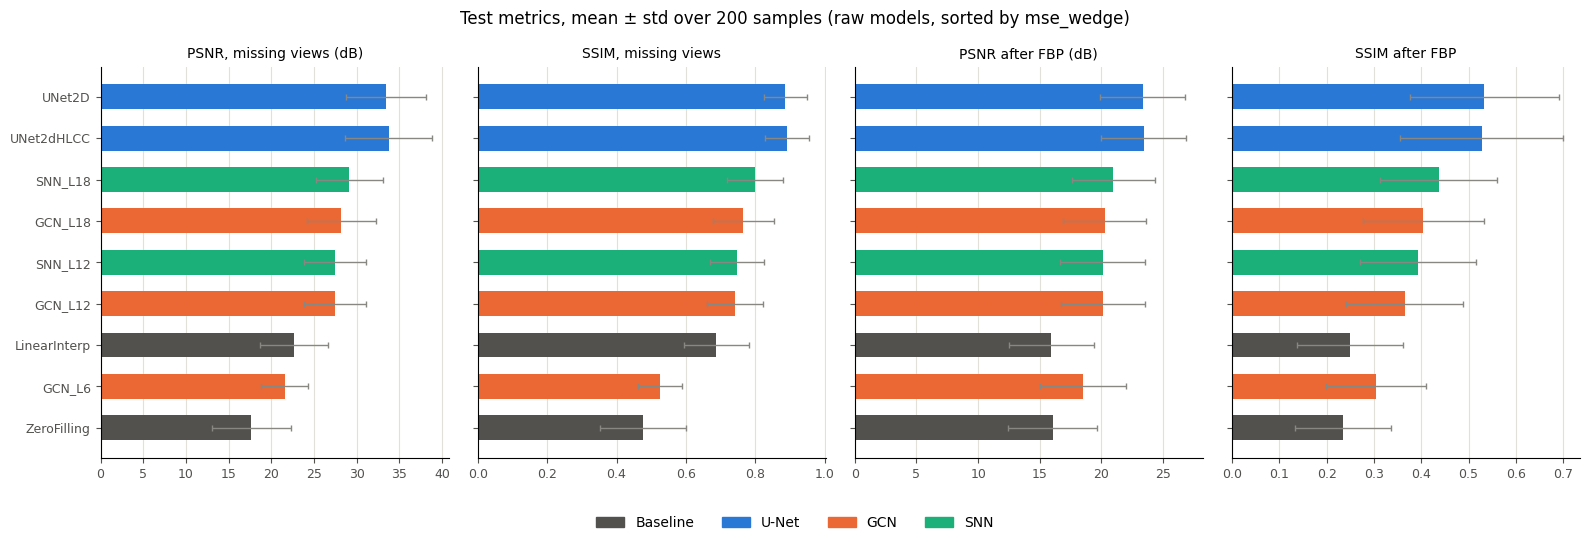

In [3]:
# Colour = model family, fixed, so that a model keeps its colour whatever its rank. Every bar is also named
# on the axis: identity never relies on colour alone.
FAMILY_COLORS = {"Baseline": "#52514e", "U-Net": "#2a78d6", "GCN": "#eb6834", "SNN": "#1baf7a"}
PLOT_METRICS = [("psnr_wedge", "PSNR, missing views (dB)"), ("ssim_wedge", "SSIM, missing views"),
                ("img_psnr", "PSNR after FBP (dB)"), ("img_ssim", "SSIM after FBP")]


def family(model_name: str) -> str:
    base, _ = parse_model_name(model_name)
    if base in BASELINES:
        return "Baseline"
    return "U-Net" if base.startswith("UNet") else base


y = np.arange(len(raw_order))
bar_colors = [FAMILY_COLORS.get(family(m), "#898781") for m in raw_order]
fig, axes = plt.subplots(1, len(PLOT_METRICS), figsize=(4 * len(PLOT_METRICS), 0.4 * len(raw_order) + 1.8), sharey=True)
for ax, (col, title) in zip(axes, PLOT_METRICS):
    ax.barh(y, mean.loc[raw_order, col], xerr=std.loc[raw_order, col], height=0.6, color=bar_colors,
            error_kw={"elinewidth": 1.0, "ecolor": "#898781", "capsize": 2})
    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#52514e", labelsize=9)
axes[0].set_yticks(y)
axes[0].set_yticklabels(raw_order)
axes[0].invert_yaxis()  # best model (lowest mse_wedge) on top

present = [f for f in FAMILY_COLORS if f in {family(m) for m in raw_order}]
fig.legend([plt.Rectangle((0, 0), 1, 1, color=FAMILY_COLORS[f]) for f in present], present,
           loc="lower center", ncol=len(present), frameon=False)
fig.suptitle(f"Test metrics, mean ± std over {n_samples} samples (raw models, sorted by mse_wedge)", fontsize=12)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

### Training cost and hardware

One row per trained network (a `_P<k>` variant is the same network followed by the HLCC moment regression: no
training, no parameter). Training time includes the validation of every epoch; GPU-hours = training time x GPUs.
Peak VRAM = peak memory allocated by PyTorch on one GPU during a training step, with the per-GPU batch of the run:
recorded by `train.py` since 2026-10-04, measured afterwards by `scripts/measure_peak_vram.py` for the earlier runs
(all trained on the 8 GPUs of the lab server).


In [4]:
peak_path = TABLE_DIR / "peak_vram.csv"
measured = pd.read_csv(peak_path).set_index("run") if peak_path.exists() else pd.DataFrame()
FAMILY_RANK = {"Baseline": 0, "U-Net": 1, "GCN": 2, "SNN": 3}
cost_order = sorted(trained_order, key=lambda m: (FAMILY_RANK.get(family(m), 9), parse_model_name(m)[1].get("num_layers", 0), m))


def recorded(stats: dict, run: str, key: str, measured_key: str):
    """A hardware field of training_stats.json, or the later measurement of scripts/measure_peak_vram.py."""
    if key in stats:
        return stats[key]
    return measured.loc[run, measured_key] if run in measured.index else np.nan


cost_rows = []
for name in cost_order:
    if parse_model_name(name)[0] in BASELINES:
        cost_rows.append({"Model": name, "Parameters": "0"})
        continue
    run = run_name_of(name)
    stats_path = CHECKPOINT_ROOT / run / "training_stats.json"
    if not stats_path.exists():
        print(f"[skipped] {name}: no {stats_path}")
        continue
    stats = json.loads(stats_path.read_text())
    seconds, epochs, gpus = stats["training_time_seconds"], stats["epochs_run"], stats.get("world_size", 1)
    repeats = stats.get("train_repeats", 1)
    cost_rows.append({
        "Model": name,
        "Parameters": f"{stats['num_params']:,}",
        "Training phantoms": f"{stats['n_samples']}" + (f" × {repeats}" if repeats > 1 else ""),
        "GPU": recorded(stats, run, "device", "gpu"),
        "GPUs": str(gpus),
        "VRAM / GPU (GiB)": f"{recorded(stats, run, 'gpu_memory_gib', 'gpu_memory_gib'):.1f}",
        "Peak VRAM / GPU (GiB)": f"{recorded(stats, run, 'peak_memory_gib', 'peak_memory_gib'):.2f}",
        "Epochs (best)": f"{epochs} ({stats['best']['best_epoch']})",
        "Training time": f"{int(seconds // 3600)} h {int(seconds % 3600 // 60):02d} min",
        "Time / epoch (s)": f"{seconds / epochs:.1f}",
        "GPU-hours": f"{seconds / 3600 * gpus:.1f}",
    })
cost_table = pd.DataFrame(cost_rows).set_index("Model").fillna("—")
display(cost_table)
export_table(cost_table, "training_cost")


,Parameters,Training phantoms,GPU,GPUs,VRAM / GPU (GiB),Peak VRAM / GPU (GiB),Epochs (best),Training time,Time / epoch (s),GPU-hours
Model,,,,,,,,,,
LinearInterp,0,—,—,—,—,—,—,—,—,—
ZeroFilling,0,—,—,—,—,—,—,—,—,—
UNet2D,"2,141,249",2000,Tesla K80,8,11.2,0.35,200 (103),0 h 51 min,15.6,6.9
UNet2D_N200,"2,141,249",200 × 10,Tesla K80,8,11.2,0.35,200 (72),0 h 51 min,15.5,6.9
UNet2dHLCC,"2,141,249",2000,Tesla K80,8,11.2,0.35,200 (145),0 h 51 min,15.6,6.9
UNet2dHLCC_N200,"2,141,249",200 × 10,Tesla K80,8,11.2,0.35,200 (93),0 h 52 min,15.6,6.9
GCN_L6,"207,585",2000,Tesla K80,8,11.2,2.04,200 (197),1 h 35 min,28.8,12.8
GCN_L12,"406,881",2000,Tesla K80,8,11.2,3.90,200 (197),2 h 58 min,53.7,23.8
GCN_L18,"606,177",2000,Tesla K80,8,11.2,5.76,200 (193),4 h 21 min,78.6,34.9


## 2. Qualitative comparison

The first `NUM_VIZ_SAMPLES` test samples (samples 0, 1, ... of the CSV), for the models of `VIZ_MODELS` (edit the
list to look at another model; the `_P4` variants are compared in sections 1 and 3 bis).
Columns: incomplete input | completed sinogram | ground truth | FBP of the ground truth | FBP of the completed sinogram.

- The three sinograms of a row share the grey scale of the ground truth, and the FBP images the range [0, 1] of the
  phantom, so that a washed-out prediction looks washed out. Dashed lines: limits of the acquired window.
- The metrics above each prediction are computed exactly as in `evaluate_all.py`; a mismatch with the CSV
  (reported at the end) means that the CSV was produced by other checkpoints.

In [5]:
torch.backends.cudnn.enabled = False  # same setting as evaluate_all.py
device = resolve_compute_device()

NUM_VIZ_SAMPLES = 3
VIZ_MODELS = ["LinearInterp", "UNet2D", "GCN_L18", "SNN_L18"]  # every raw model stays loaded (section 4)
NOISE_LEVEL = 1e5  # must match the --noise_level of evaluate_all.py

geometry_config = DBTGeometryConfig()
geom = DBTGeometry.from_config(geometry_config)
missing_views = ~geom.acquired_view_mask
proj_geom, vol_geom = build_full_astra_geometries(geometry_config, geometry_config.image_shape)
# Test samples are drawn from a per-index seed: sample i here is sample i of the CSV.
dataset = SinogramCompletionDataset(NUM_VIZ_SAMPLES, split="test", noise_level=NOISE_LEVEL, geometry_config=geometry_config)

step = geometry_config.angle_step_deg
angles_deg = np.rad2deg(geom.angles)
det_half_mm = geometry_config.det_col_count * geometry_config.det_pixel_size_mm / 2.0
sino_extent = [angles_deg[0] - step / 2, angles_deg[-1] + step / 2, -det_half_mm, det_half_mm]
image_extent = [*geometry_config.image_extent_mm[1], *geometry_config.image_extent_mm[0]]
window_edges = [geometry_config.angle_min_deg - step / 2, geometry_config.angle_max_deg + step / 2]

models = {}
for name in raw_order:
    try:
        models[name], _ = get_model(name, device, geometry_config=geometry_config)
    except (FileNotFoundError, ValueError, RuntimeError) as exc:
        print(f"[skipped] {name}: {str(exc).splitlines()[0]}")
print(f"Loaded {len(models)} models: {list(models)}")

[+] Loaded UNet2D from /home/jdq/Master_Thesis/outputs/2d/checkpoints/UNet2D/best_model.pt (config: {'filters': 32})
[+] Loaded UNet2dHLCC from /home/jdq/Master_Thesis/outputs/2d/checkpoints/UNet2dHLCC/best_model.pt (config: {'filters': 32})


[+] Loaded SNN_L18 from /home/jdq/Master_Thesis/outputs/2d/checkpoints/SNN_L18/best_model.pt (config: {'num_stalks': 32, 'num_layers': 18, 'k': 12, 'sigma_deg': 5.0, 'graph_type': 'knn', 'normalization': 'sym', 'grad_checkpoint': False})
[+] Loaded GCN_L18 from /home/jdq/Master_Thesis/outputs/2d/checkpoints/GCN_L18/best_model.pt (config: {'num_stalks': 32, 'num_layers': 18, 'k': 12, 'sigma_deg': 5.0, 'graph_type': 'knn', 'normalization': 'sym', 'grad_checkpoint': False})
[+] Loaded SNN_L12 from /home/jdq/Master_Thesis/outputs/2d/checkpoints/SNN_L12/best_model.pt (config: {'num_stalks': 32, 'num_layers': 12, 'k': 12, 'sigma_deg': 5.0, 'graph_type': 'knn', 'normalization': 'sym', 'grad_checkpoint': False})
[+] Loaded GCN_L12 from /home/jdq/Master_Thesis/outputs/2d/checkpoints/GCN_L12/best_model.pt (config: {'num_stalks': 32, 'num_layers': 12, 'k': 12, 'sigma_deg': 5.0, 'graph_type': 'knn', 'normalization': 'sym', 'grad_checkpoint': False})
[+] Loaded GCN_L6 from /home/jdq/Master_Thesis/o

Loaded 9 models: ['UNet2D', 'UNet2dHLCC', 'SNN_L18', 'GCN_L18', 'SNN_L12', 'GCN_L12', 'LinearInterp', 'GCN_L6', 'ZeroFilling']


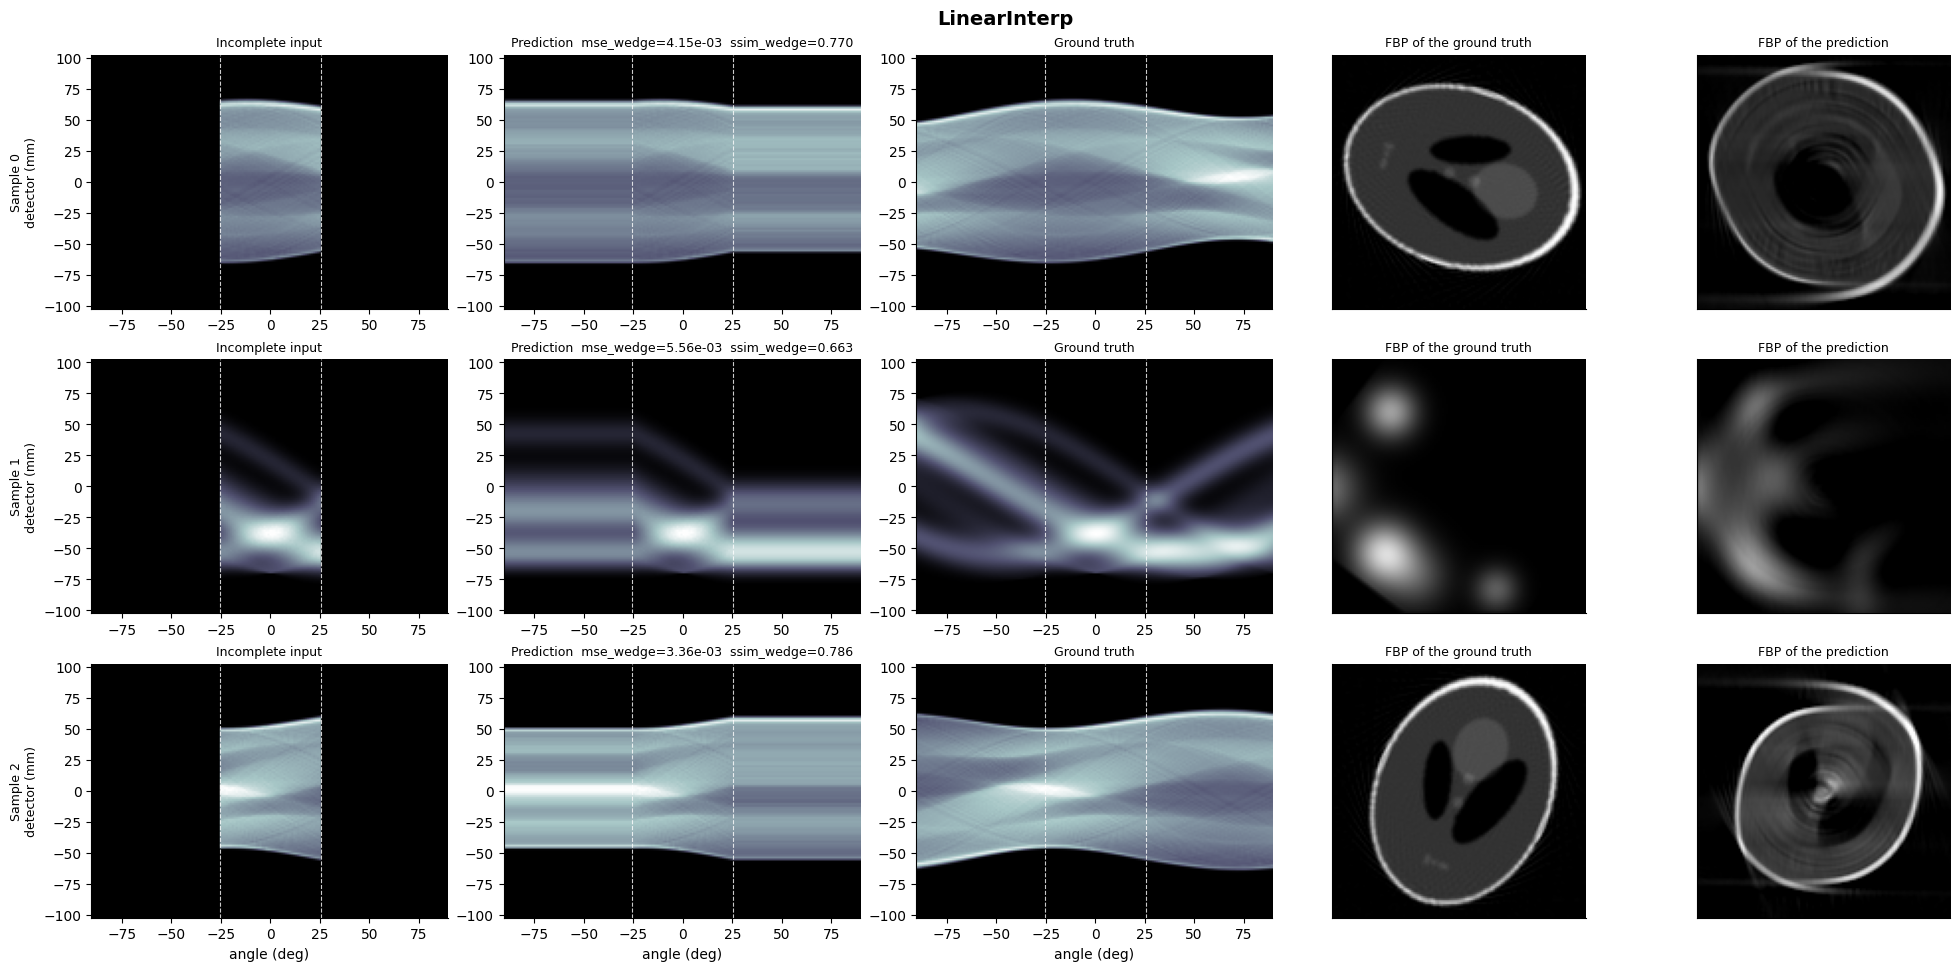

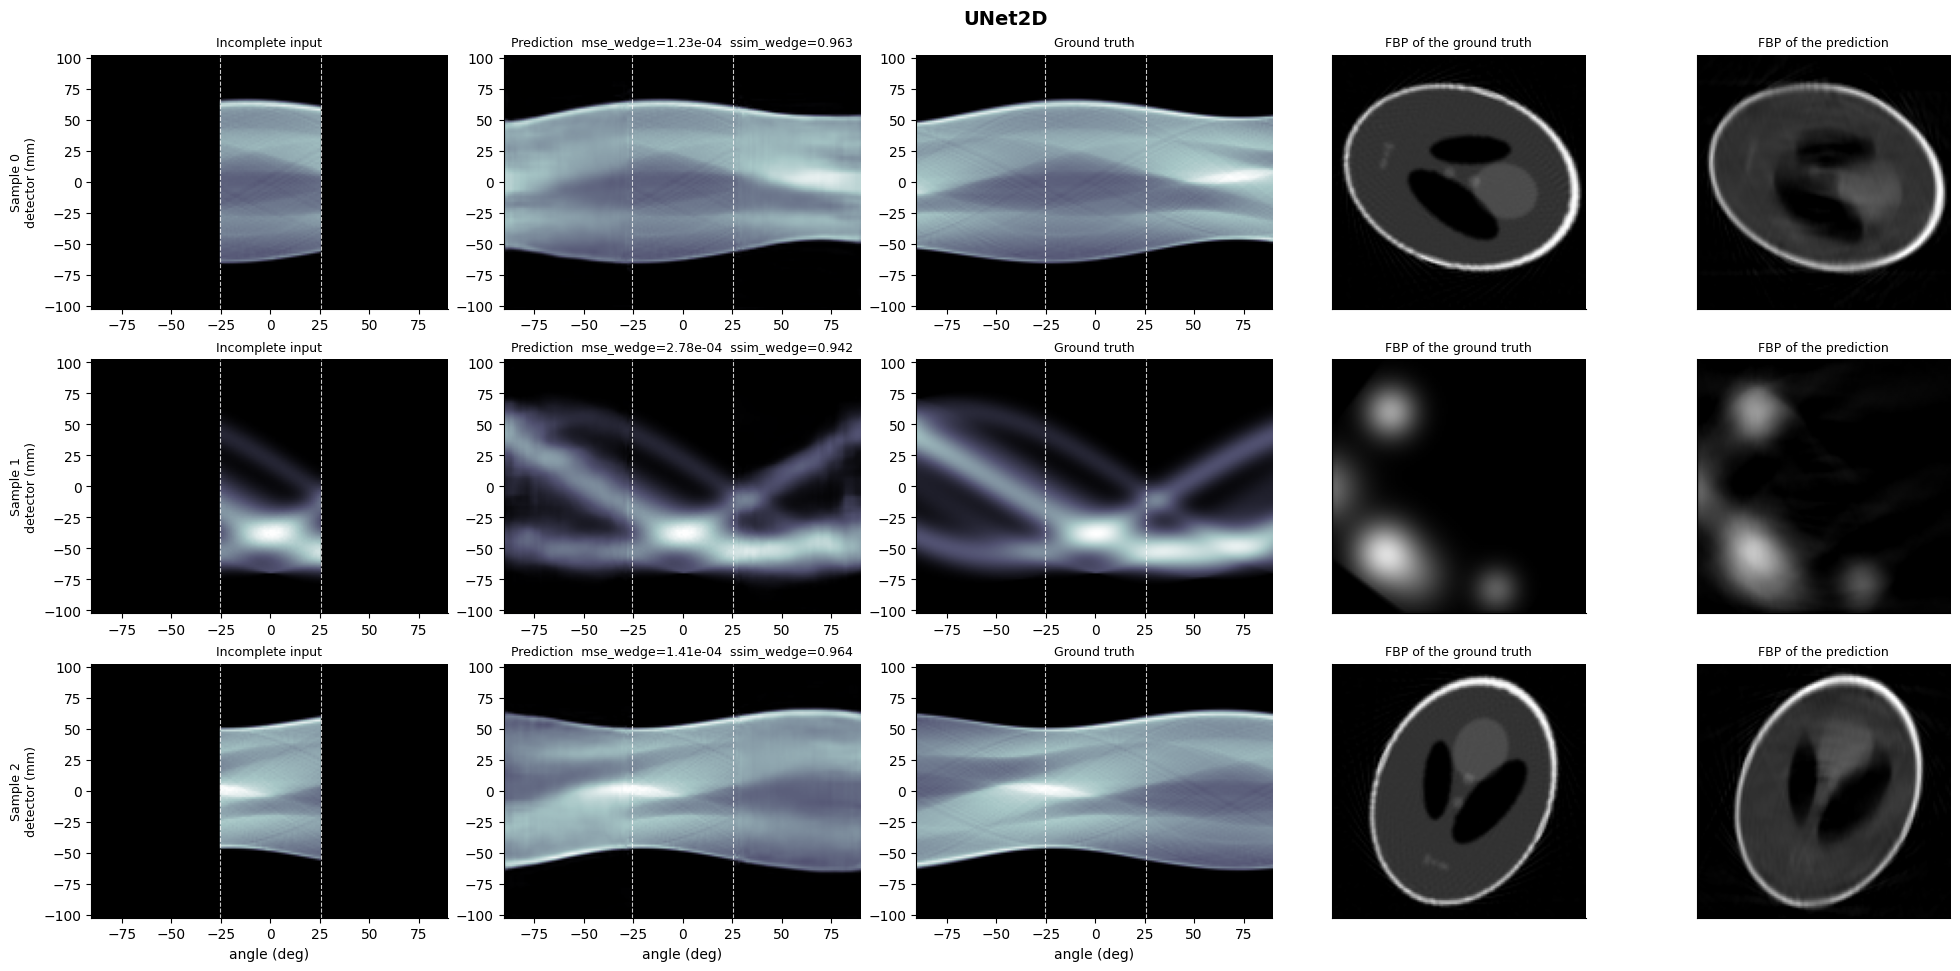

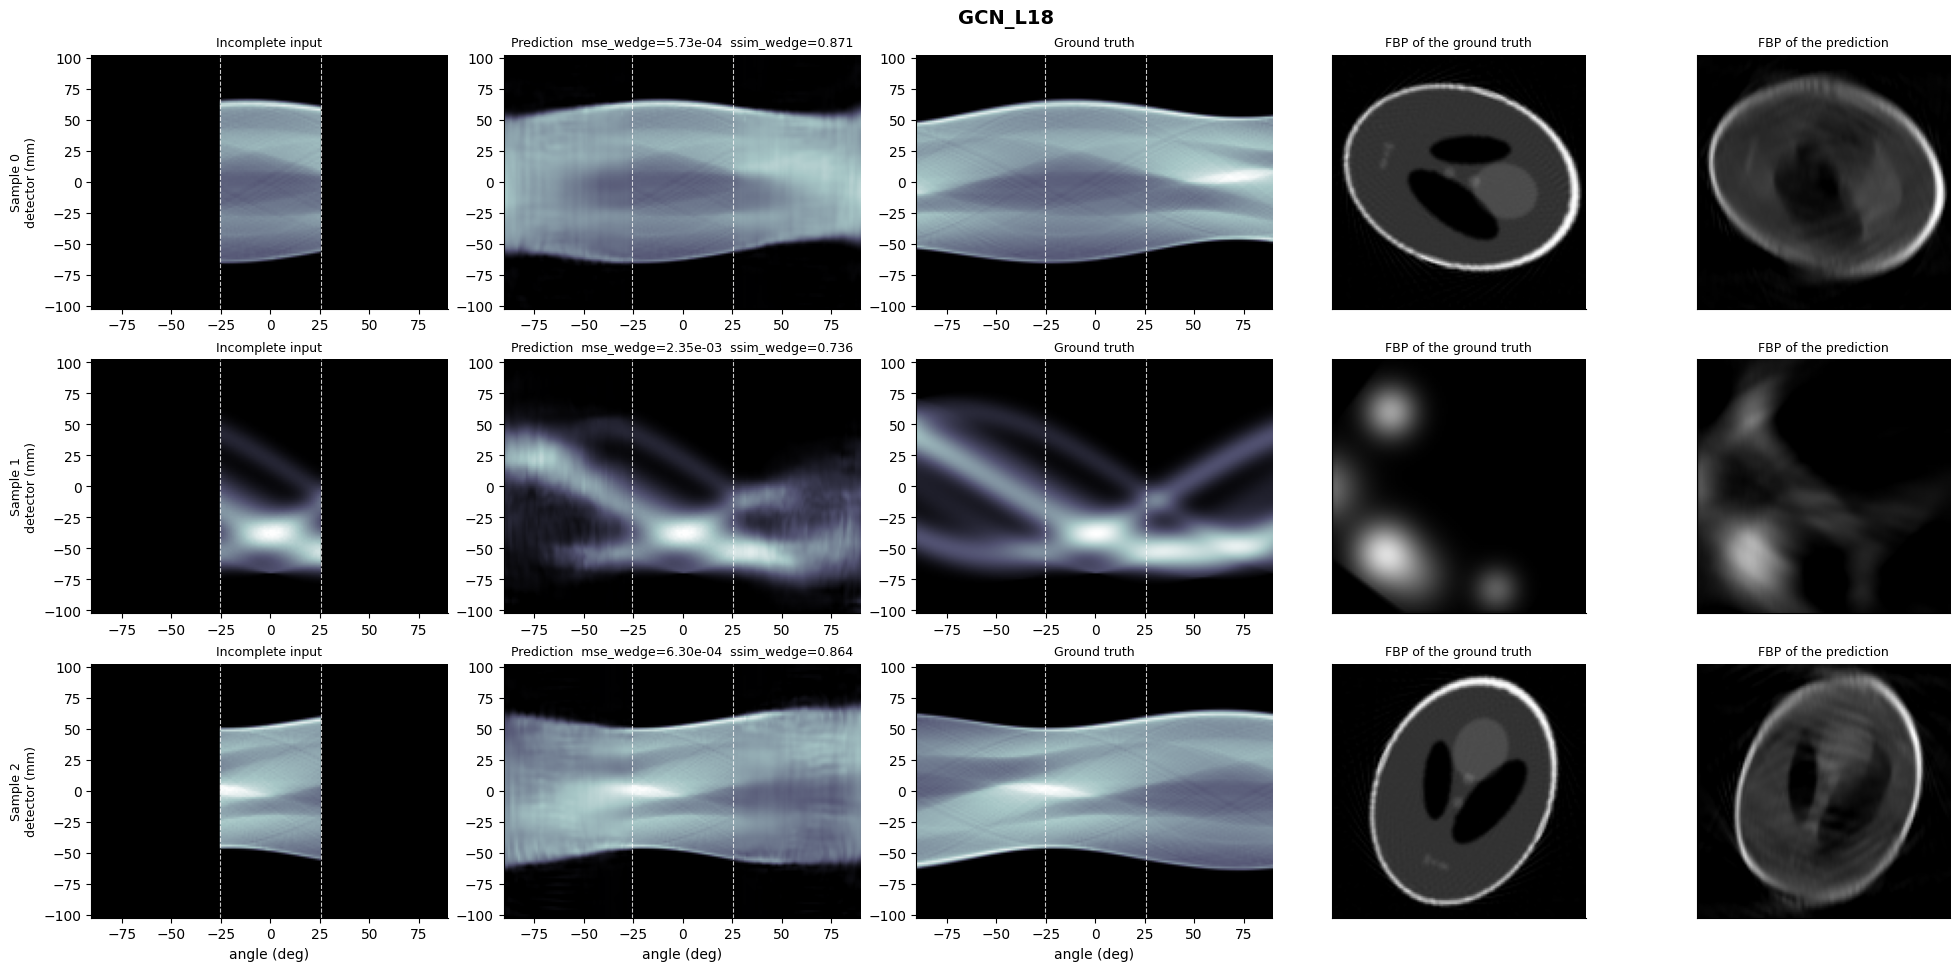

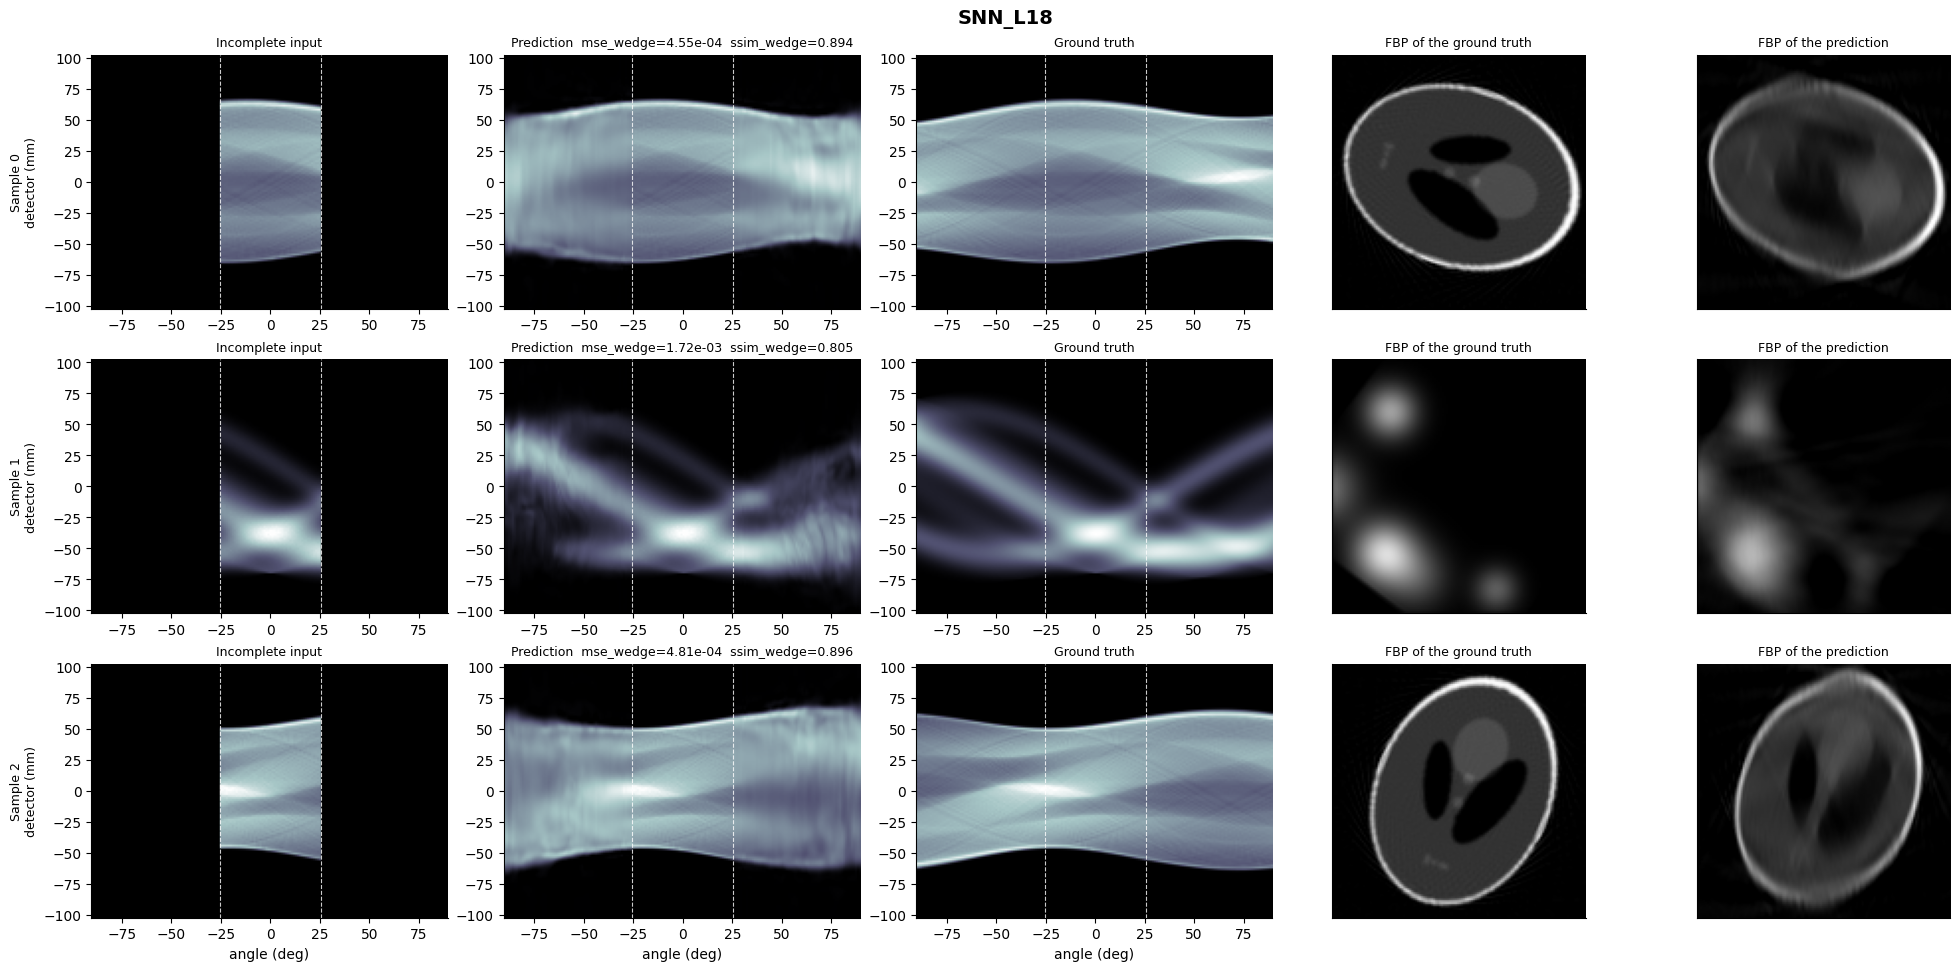

The per-sample metrics match the CSV.


In [6]:
@torch.no_grad()
def complete(model, incomplete: torch.Tensor) -> np.ndarray:
    """Every model, learned or not, shares the interface [B, 1, V, D] -> [B, 1, V, D]."""
    return model(incomplete.unsqueeze(0).to(device))[0, 0].float().cpu().numpy()


def fbp(sinogram: np.ndarray) -> np.ndarray:
    """FBP of a normalised sinogram, in the units of the phantom (as in evaluate_all.py)."""
    return reconstruct_volume_fbp(sinogram * geometry_config.sino_norm, proj_geom, vol_geom)


samples = [dataset[i] for i in range(NUM_VIZ_SAMPLES)]
ground_truth_fbp = [fbp(full[0].numpy()) for _, full, _ in samples]
stale = set()

for name in [m for m in VIZ_MODELS if m in models]:
    model = models[name]
    fig, axes = plt.subplots(NUM_VIZ_SAMPLES, 5, figsize=(20, 3.2 * NUM_VIZ_SAMPLES), squeeze=False, layout="constrained")
    for i, (incomplete, full, _) in enumerate(samples):
        inc_np, full_np = incomplete[0].numpy(), full[0].numpy()
        pred_np = complete(model, incomplete)
        m = sinogram_metrics(pred_np, full_np, missing_views)

        csv_row = results[(results["Sample"] == i) & (results["Model"] == name)]
        if not csv_row.empty and not np.isclose(csv_row["mse_wedge"].iloc[0], m["mse_wedge"], rtol=1e-3):
            stale.add(name)

        sinograms = [(inc_np, "Incomplete input"),
                     (pred_np, f"Prediction  mse_wedge={m['mse_wedge']:.2e}  ssim_wedge={m['ssim_wedge']:.3f}"),
                     (full_np, "Ground truth")]
        for ax, (sino, title) in zip(axes[i, :3], sinograms):
            ax.imshow(sino.T, cmap="bone", origin="lower", aspect="auto", extent=sino_extent, vmin=0.0, vmax=full_np.max())
            for edge in window_edges:
                ax.axvline(edge, color="white", alpha=0.8, linestyle="--", linewidth=0.8)
            ax.set_title(title, fontsize=9)
        axes[i, 0].set_ylabel(f"Sample {i}\ndetector (mm)", fontsize=9)

        images = [(ground_truth_fbp[i], "FBP of the ground truth"), (fbp(pred_np), "FBP of the prediction")]
        for ax, (image, title) in zip(axes[i, 3:], images):
            ax.imshow(image, cmap="gray", origin="lower", extent=image_extent, vmin=0.0, vmax=1.0)
            ax.set_title(title, fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
    for ax in axes[-1, :3]:
        ax.set_xlabel("angle (deg)")
    fig.suptitle(name, fontsize=14, fontweight="bold")
    plt.show()

if stale:
    print(f"WARNING: the CSV does not match the current checkpoints of {sorted(stale)}: re-run evaluate_all.py.")
else:
    print("The per-sample metrics match the CSV.")

## 3. Angular reach of the graph models

x axis: angular distance $d$ between a missing view and the acquired window (both sides of the wedge folded together).
A graph model with $L$ layers and $k$ neighbours per view cannot receive any measurement at $d > L \cdot k/2$ views
($6L$ degrees for $k = 12$): its output there is **identical for every sample**, so its per-view MSE cannot go below the
**floor**, the inter-sample variance of the ground truth (the error of the best prediction that ignores the measurements).

- Left: per-view MSE and floor. Right: $\rho(d)$ = std over the samples of the prediction / std over the samples of the
  ground truth, i.e. the share of the real variability that the model reproduces (exactly 0 beyond the reach).
- Colour = model family (as in section 1), line style = depth (solid: 6 layers, dashed: 12, dotted: 18).
- The table checks the theorem on the trained models: beyond the reach, the inter-sample std of the prediction must be
  0 and MSE / floor must be ≥ 1. The references (U-Net, interpolation) are split at the reach of 6 layers, as a control.
- Only the raw graph models are checked: a `_P4` model adds the moment regression, fitted on the acquired views, so
  beyond the reach it does depend on the measurements (section 3 bis).

In [7]:
from src_2D.models.SinoSheavesNN.graph_data import angular_reach_deg
from src_2D.models.factory import GRAPH_MODELS
from src_2D.utils.checkpoint import load_checkpoint

PROTOCOL_K, PROTOCOL_DEPTHS = 12, (6, 12, 18)
DEPTH_STYLES = {6: "-", 12: "--", 18: ":"}
REFERENCE_MODELS = ["UNet2D", "LinearInterp"]

geometry_config = DBTGeometryConfig()
step = geometry_config.angle_step_deg
per_view_mse = pd.read_csv(EVAL_DIR / "per_view_mse.csv")
var_path = EVAL_DIR / "per_view_var.csv"
per_view_var = pd.read_csv(var_path) if var_path.exists() else None
if per_view_var is None:
    print(f"{var_path} is missing: re-run python src_2D/evaluate_all.py to get the floor and the right panel.")

# Angular distance of every missing view to the acquired window, on the grid of the angular step.
view_angles = per_view_mse["angle_deg"].to_numpy()
wedge = ~per_view_mse["acquired"].to_numpy(dtype=bool)
distance_deg = np.maximum(geometry_config.angle_min_deg - view_angles, view_angles - geometry_config.angle_max_deg)
wedge_distance = np.rint(distance_deg[wedge] / step) * step


def fold(per_view_values) -> pd.Series:
    """Mean of a per-view quantity over the missing views at the same distance to the window."""
    return pd.Series(np.asarray(per_view_values)[wedge]).groupby(wedge_distance).mean()


def depth(model_name: str):
    return parse_model_name(model_name)[1].get("num_layers")


def reach_deg(model_name: str) -> float:
    """Angular reach of a trained graph model, from the configuration stored in its checkpoint."""
    config = load_checkpoint(CHECKPOINT_ROOT / run_name_of(model_name) / "best_model.pt")["model_config"]
    return angular_reach_deg(config["num_layers"], config["k"], step, config.get("graph_type", "knn"))


model_columns = [c for c in per_view_mse.columns if c not in ("angle_deg", "acquired")]
graph_models = [m for m in model_columns if parse_model_name(m)[0] in GRAPH_MODELS and not is_projected(m)]
projected_graph_models = [m for m in model_columns if parse_model_name(m)[0] in GRAPH_MODELS and is_projected(m)]
references = [m for m in REFERENCE_MODELS if m in model_columns]
floor = fold(per_view_var["GroundTruth"]) if per_view_var is not None else None
print(f"Graph models: {graph_models or 'none evaluated yet'} | references: {references}")

Graph models: ['GCN_L6', 'GCN_L12', 'GCN_L18', 'SNN_L12', 'SNN_L18'] | references: ['UNet2D', 'LinearInterp']


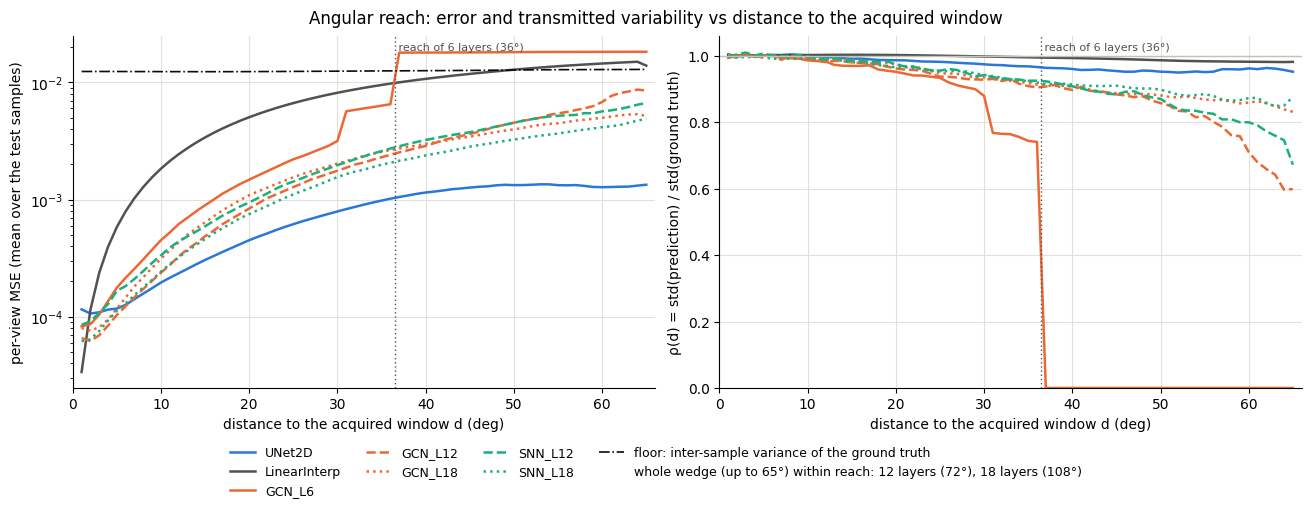

In [8]:
from matplotlib.lines import Line2D

fig, (ax_mse, ax_rho) = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for name in references + graph_models:
    style = {"color": FAMILY_COLORS.get(family(name), "#898781"), "linestyle": DEPTH_STYLES.get(depth(name), "-"),
             "linewidth": 1.8, "label": name}
    curve = fold(per_view_mse[name])
    ax_mse.plot(curve.index, curve.to_numpy(), **style)
    if per_view_var is not None:
        rho = np.sqrt(fold(per_view_var[name]) / floor)
        ax_rho.plot(rho.index, rho.to_numpy(), **style)
if floor is not None:
    ax_mse.plot(floor.index, floor.to_numpy(), color="#0b0b0b", linestyle="-.", linewidth=1.2,
                label="floor: inter-sample variance of the ground truth")

# Reach of the protocol depths: a vertical line between the last reachable view and the next one.
d_max = wedge_distance.max()
covering = []
for L in PROTOCOL_DEPTHS:
    reach = angular_reach_deg(L, PROTOCOL_K, step)
    if reach >= d_max:
        covering.append(f"{L} layers ({reach:.0f}°)")
        continue
    for ax in (ax_mse, ax_rho):
        ax.axvline(reach + step / 2, color="#52514e", linewidth=1.0, linestyle=(0, (1, 2)))
        ax.text(reach + step / 2, 0.98, f" reach of {L} layers ({reach:.0f}°)", transform=ax.get_xaxis_transform(),
                va="top", fontsize=8, color="#52514e")
ax_mse.set_yscale("log")
ax_mse.set_ylabel("per-view MSE (mean over the test samples)")
ax_rho.set_ylabel("ρ(d) = std(prediction) / std(ground truth)")
ax_rho.axhline(1.0, color="#c3c2b7", linewidth=1.0)
ax_rho.set_ylim(bottom=0.0)
for ax in (ax_mse, ax_rho):
    ax.set_xlabel("distance to the acquired window d (deg)")
    ax.set_xlim(0.0, d_max + step)
    ax.grid(color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
handles, labels = ax_mse.get_legend_handles_labels()
if covering:  # text-only legend entry
    handles.append(Line2D([], [], linestyle="none"))
    labels.append(f"whole wedge (up to {d_max:.0f}°) within reach: " + ", ".join(covering))
fig.legend(handles, labels, loc="outside lower center", ncol=4, frameon=False, fontsize=9)
fig.suptitle("Angular reach: error and transmitted variability vs distance to the acquired window", fontsize=12)
fig.savefig(FIG_DIR / "angular_reach.pdf", bbox_inches="tight")
plt.show()

In [9]:
STD_COL, RATIO_COL = "max std beyond (theory: 0)", "min MSE / floor beyond (theory: ≥ 1)"
l6_reach = angular_reach_deg(PROTOCOL_DEPTHS[0], PROTOCOL_K, step)
rows = []
for name in graph_models + references:
    split = reach_deg(name) if name in graph_models else l6_reach
    beyond = wedge_distance > split
    mse_views = per_view_mse[name].to_numpy()[wedge]
    row = {"Model": name, "split at d (deg)": split,
           "views beyond": f"{beyond.sum()} / {wedge.sum()} ({beyond.mean():.0%})",
           "MSE within reach": mse_views[~beyond].mean() if (~beyond).any() else np.nan,
           "MSE beyond reach": mse_views[beyond].mean() if beyond.any() else np.nan}
    if name in graph_models and per_view_var is not None and beyond.any():
        pred_var = per_view_var[name].to_numpy()[wedge][beyond]
        gt_var = per_view_var["GroundTruth"].to_numpy()[wedge][beyond]
        row[STD_COL] = np.sqrt(pred_var.max())
        row[RATIO_COL] = (mse_views[beyond] / gt_var).min()
    rows.append(row)

if rows:
    reach_table = pd.DataFrame(rows).set_index("Model")
    display(reach_table)
    export_table(reach_table, "angular_reach")
    if STD_COL in reach_table:
        for name, row in reach_table.dropna(subset=[STD_COL]).iterrows():
            holds = row[STD_COL] == 0.0 and row[RATIO_COL] >= 1.0 - 1e-9
            verdict = ("identical for every sample and above the floor: theorem verified" if holds
                       else "NOT independent of the measurements: check the model and the evaluation")
            print(f"{name}: beyond {row['split at d (deg)']:.0f}°, the output is {verdict}.")
else:
    print("Nothing to check yet: evaluate the models first (python src_2D/evaluate_all.py).")

,split at d (deg),views beyond,MSE within reach,MSE beyond reach,max std beyond (theory: 0),min MSE / floor beyond (theory: ≥ 1)
Model,,,,,,
GCN_L6,36.0,57 / 129 (44%),0.001987,0.018149,0.0,1.394116
GCN_L12,72.0,0 / 129 (0%),0.002699,NaN,NaN,NaN
GCN_L18,108.0,0 / 129 (0%),0.002399,NaN,NaN,NaN
SNN_L12,72.0,0 / 129 (0%),0.002608,NaN,NaN,NaN
SNN_L18,108.0,0 / 129 (0%),0.001926,NaN,NaN,NaN
UNet2D,36.0,57 / 129 (44%),0.000458,0.001268,NaN,NaN
LinearInterp,36.0,57 / 129 (44%),0.004621,0.012820,NaN,NaN


GCN_L6: beyond 36°, the output is identical for every sample and above the floor: theorem verified.


## 3 bis. Graph models followed by the HLCC moment regression (P4)

`<model>_P4` is the completed sinogram of the model whose moments of orders 0 to 4 on the missing views are replaced by
their harmonic extension fitted on the acquired views (Huang et al. 2017, `src_2D/utils/hlcc.py`, no training). The
regression reads **only the acquired views**, so beyond the reach of a graph model it brings information from the
measurements back: $\rho(d)$ is no longer 0 and the error is no longer bounded by the floor. It fixes about 15 numbers
per sinogram (`docs/harmonic_sheaves.md`, section 5.4), so the gain beyond the reach measures how much of the error
there is low-order.

One column per depth. Top: per-view MSE (log scale) and floor. Bottom: $\rho(d)$. Raw model: solid line, colour of its
family; with the regression: dashed violet line.


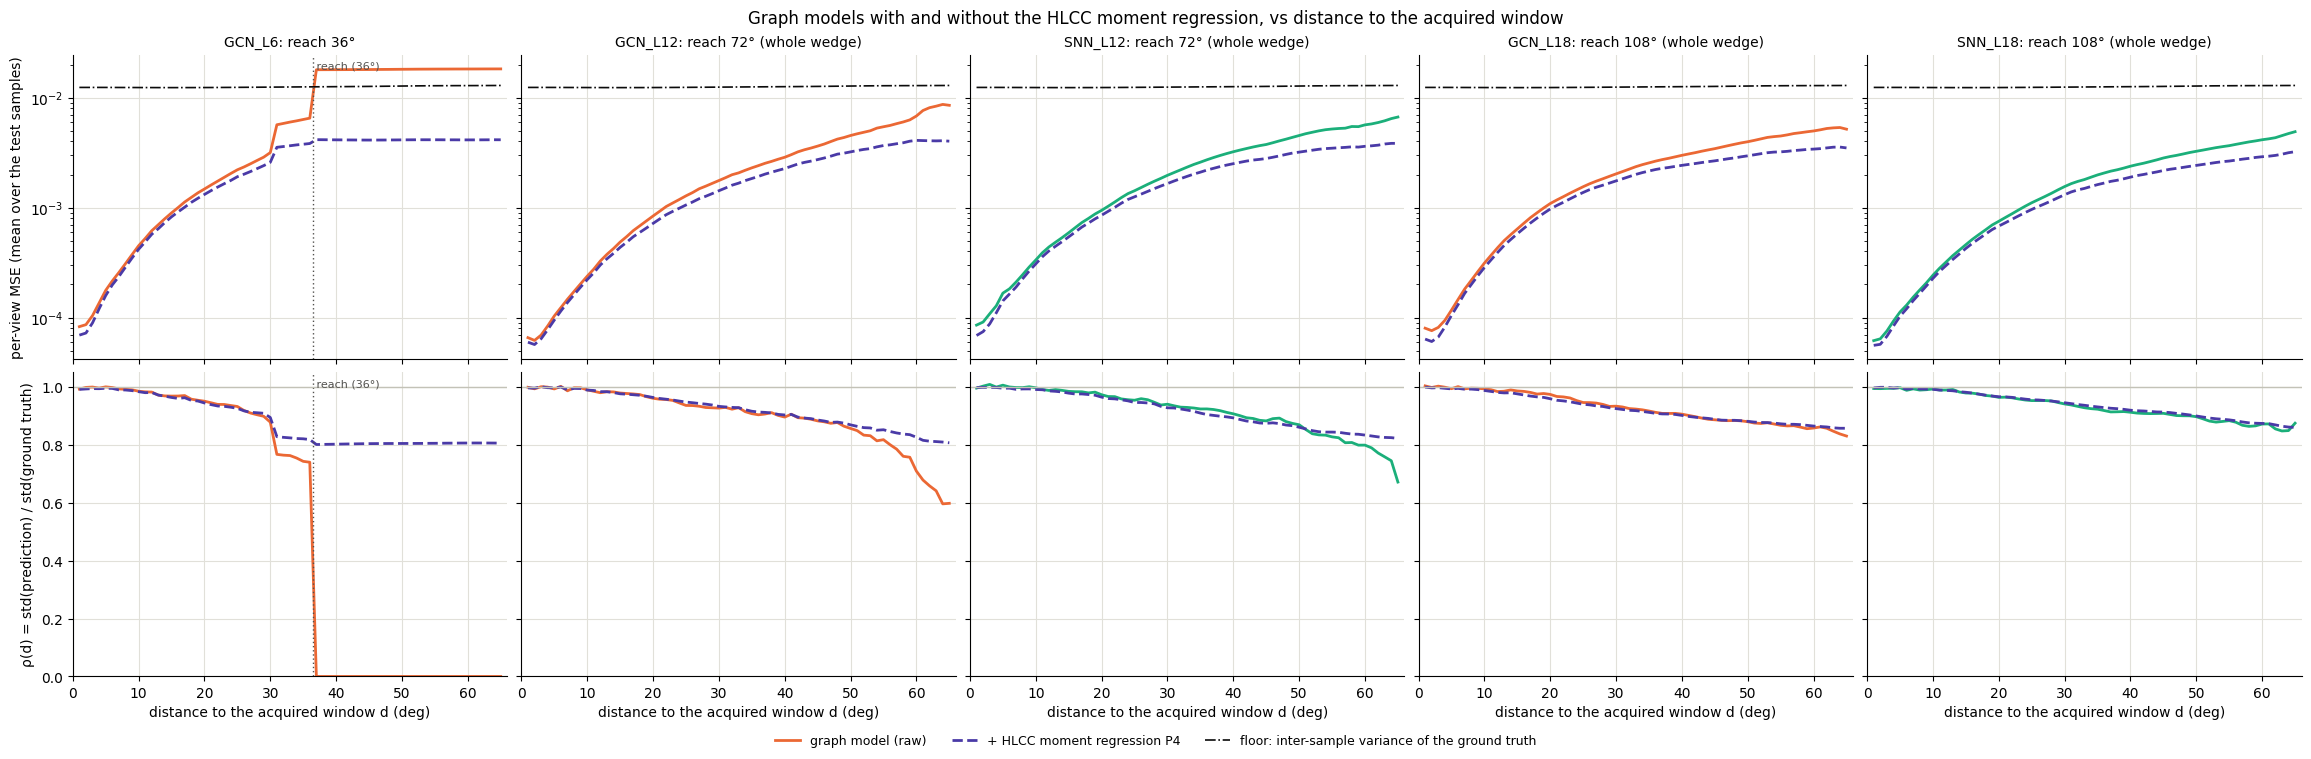

,MSE wedge,MSE within reach,MSE beyond reach,MSE / floor beyond,ρ beyond
Model,,,,,
GCN_L6,0.00913,0.00199,0.0181,1.42,0
GCN_L6_P4,0.00264,0.00146,0.00414,0.324,0.805
GCN_L12,0.0027,0.0027,NaN,NaN,NaN
GCN_L12_P4,0.00184,0.00184,NaN,NaN,NaN
SNN_L12,0.00261,0.00261,NaN,NaN,NaN
SNN_L12_P4,0.00189,0.00189,NaN,NaN,NaN
GCN_L18,0.0024,0.0024,NaN,NaN,NaN
GCN_L18_P4,0.00184,0.00184,NaN,NaN,NaN
SNN_L18,0.00193,0.00193,NaN,NaN,NaN


In [10]:
P4_COLOR = "#4a3aa7"  # violet, darker than every family colour: the raw / projected pair also differs by lightness
p4_pairs = sorted(((unprojected(m), m) for m in projected_graph_models if unprojected(m) in graph_models),
                  key=lambda pair: depth(pair[0]))

if not p4_pairs:
    print("No graph model evaluated with its _P4 variant: run evaluate_all.py with e.g. --models GCN_L6 GCN_L6_P4.")
else:
    fig, axes = plt.subplots(2, len(p4_pairs), figsize=(4.6 * len(p4_pairs), 7.5), squeeze=False,
                             sharex=True, sharey="row", layout="constrained")
    for col, (raw, projected) in enumerate(p4_pairs):
        ax_mse, ax_rho = axes[0, col], axes[1, col]
        for name, color, linestyle, label in ((raw, FAMILY_COLORS.get(family(raw), "#898781"), "-", "graph model (raw)"),
                                              (projected, P4_COLOR, "--", "+ HLCC moment regression P4")):
            curve = fold(per_view_mse[name])
            ax_mse.plot(curve.index, curve.to_numpy(), color=color, linestyle=linestyle, linewidth=2.0, label=label)
            if per_view_var is not None:
                rho = np.sqrt(fold(per_view_var[name]) / floor)
                ax_rho.plot(rho.index, rho.to_numpy(), color=color, linestyle=linestyle, linewidth=2.0, label=label)
        if floor is not None:
            ax_mse.plot(floor.index, floor.to_numpy(), color="#0b0b0b", linestyle="-.", linewidth=1.2,
                        label="floor: inter-sample variance of the ground truth")
        reach = reach_deg(raw)
        if reach < d_max:
            for ax in (ax_mse, ax_rho):
                ax.axvline(reach + step / 2, color="#52514e", linewidth=1.0, linestyle=(0, (1, 2)))
                ax.text(reach + step / 2, 0.98, f" reach ({reach:.0f}°)", transform=ax.get_xaxis_transform(),
                        va="top", fontsize=8, color="#52514e")
        ax_mse.set_title(f"{raw}: reach {reach:.0f}°" + (" (whole wedge)" if reach >= d_max else ""), fontsize=10)
        ax_mse.set_yscale("log")
        ax_rho.axhline(1.0, color="#c3c2b7", linewidth=1.0)
        ax_rho.set_ylim(bottom=0.0)
        ax_rho.set_xlabel("distance to the acquired window d (deg)")
        for ax in (ax_mse, ax_rho):
            ax.set_xlim(0.0, d_max + step)
            ax.grid(color="#e1e0d9", linewidth=0.8)
            ax.set_axisbelow(True)
    axes[0, 0].set_ylabel("per-view MSE (mean over the test samples)")
    axes[1, 0].set_ylabel("ρ(d) = std(prediction) / std(ground truth)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False, fontsize=9)
    fig.suptitle("Graph models with and without the HLCC moment regression, vs distance to the acquired window", fontsize=12)
    fig.savefig(FIG_DIR / "angular_reach_p4.pdf", bbox_inches="tight")
    plt.show()

    rows = []
    gt_var = per_view_var["GroundTruth"].to_numpy()[wedge] if per_view_var is not None else None
    for raw, projected in p4_pairs:
        beyond = wedge_distance > reach_deg(raw)
        for name in (raw, projected):
            mse_views = per_view_mse[name].to_numpy()[wedge]
            row = {"Model": name, "MSE wedge": mse_views.mean(), "MSE within reach": mse_views[~beyond].mean(),
                   "MSE beyond reach": mse_views[beyond].mean() if beyond.any() else np.nan}
            if gt_var is not None and beyond.any():
                row["MSE / floor beyond"] = (mse_views[beyond] / gt_var[beyond]).mean()
                row["ρ beyond"] = np.sqrt(per_view_var[name].to_numpy()[wedge][beyond] / gt_var[beyond]).mean()
            rows.append(row)
    p4_reach_table = pd.DataFrame(rows).set_index("Model")
    with pd.option_context("display.float_format", "{:.3g}".format):
        display(p4_reach_table)
    export_table(p4_reach_table, "angular_reach_p4")


## 4. Oversmoothing: GCN vs SNN at 12 and 18 layers

The SNN is the shift-transport model (`docs/harmonic_sheaves.md`, section 6 bis), trained with the Optuna configuration
of the GCN of the same depth: the two models differ only by their restriction maps. It is not trained at 6 layers
(reach-limited for both models, decision D3).

At 12 and 18 layers the whole wedge is within reach (72° and 108° > 65°), so a washed-out wedge can no longer come from
the reach: it is the signature of the diffusion itself. At 6 layers the grey band beyond 36° exists for **both** models
and is the reach effect of section 3, so 6 layers stay out of the criterion (decision D3 of the plan).

1. Qualitative: sinograms, error maps (common scale per row) and FBP on test samples fixed before looking at the
   results (`OVERSMOOTHING_SAMPLES`).
2. Angular profiles $p(\theta, s_0)$ at a few detector positions: is the sinusoidal trace continued or flattened?
3. Per test sample (`evaluate_all.py`): `mse_wedge` and the Dirichlet-energy ratios prediction / ground truth on the
   wedge, along the angle and along the detector (1: as much variation as the ground truth, < 1: smoother).
4. Criterion fixed in advance (plan, section 4.2): the SNN beats the GCN at 12 **and** 18 layers, on `mse_wedge`
   **and** on the angular ratio (closer to 1, i.e. smaller $|\log \text{ratio}|$), each with a paired Wilcoxon test
   p < 0.05 on the same test samples.

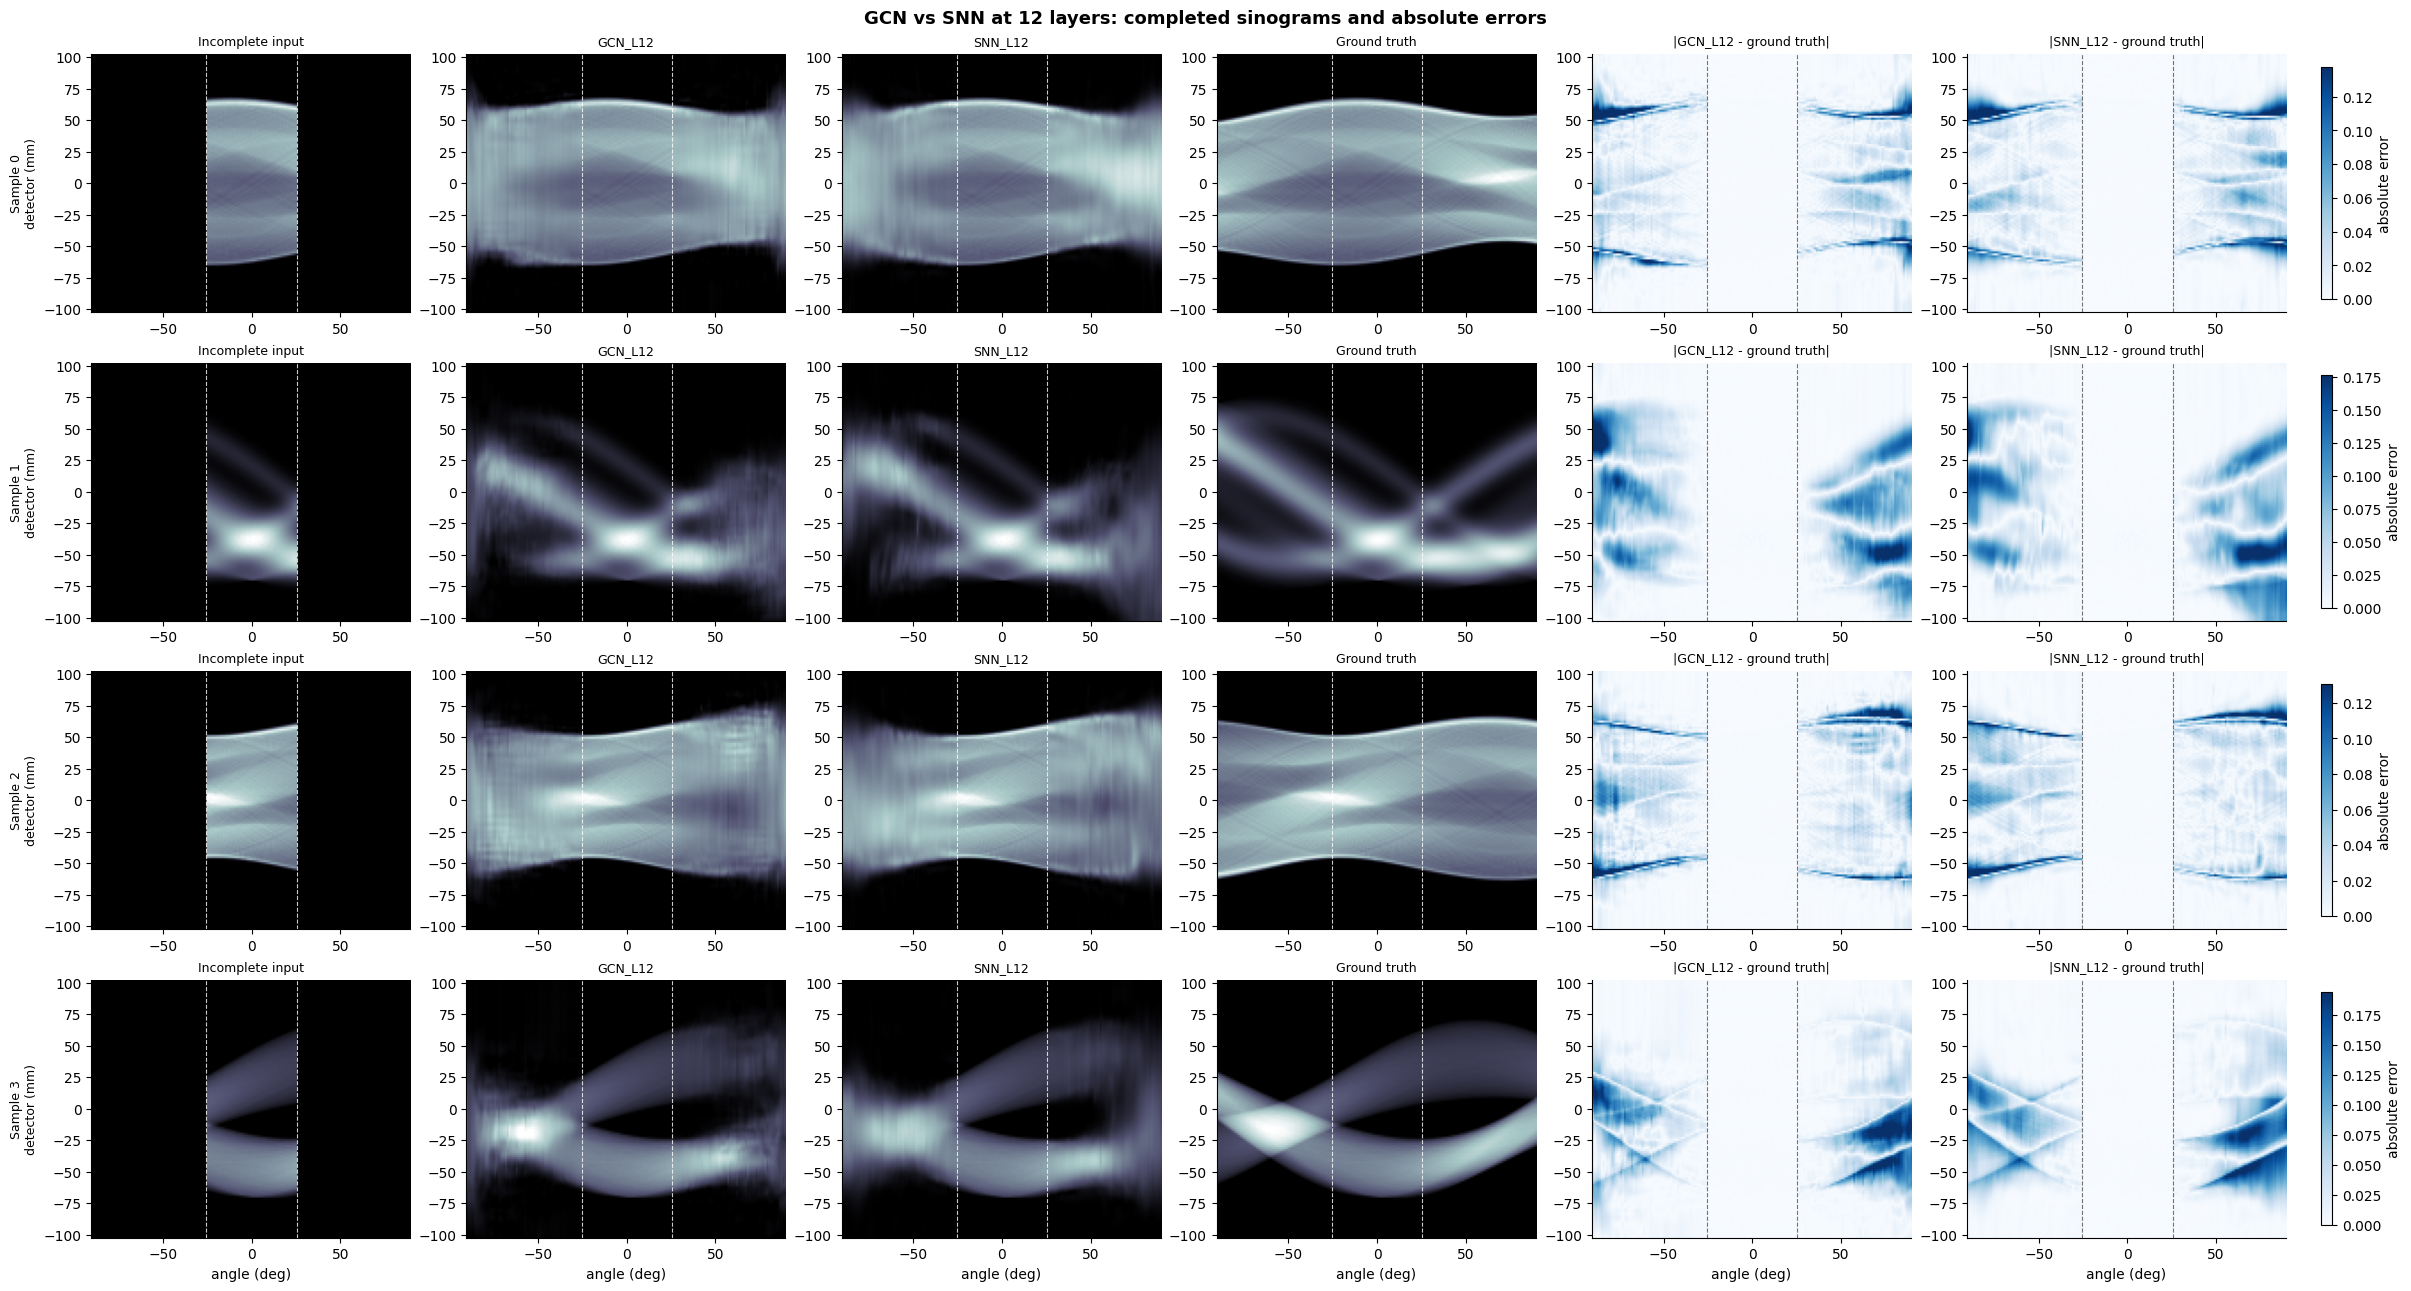

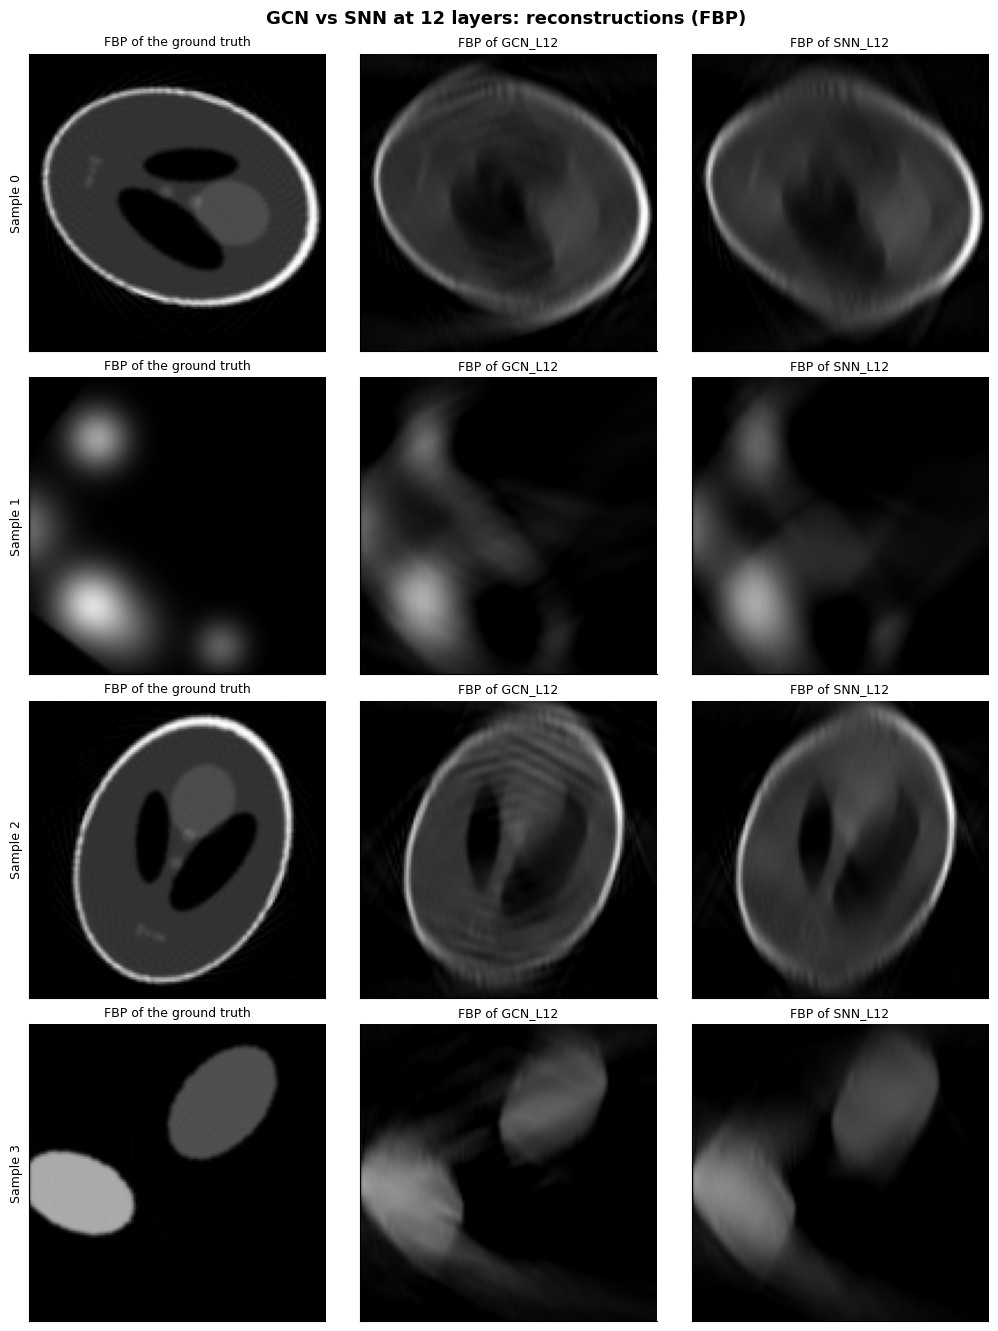

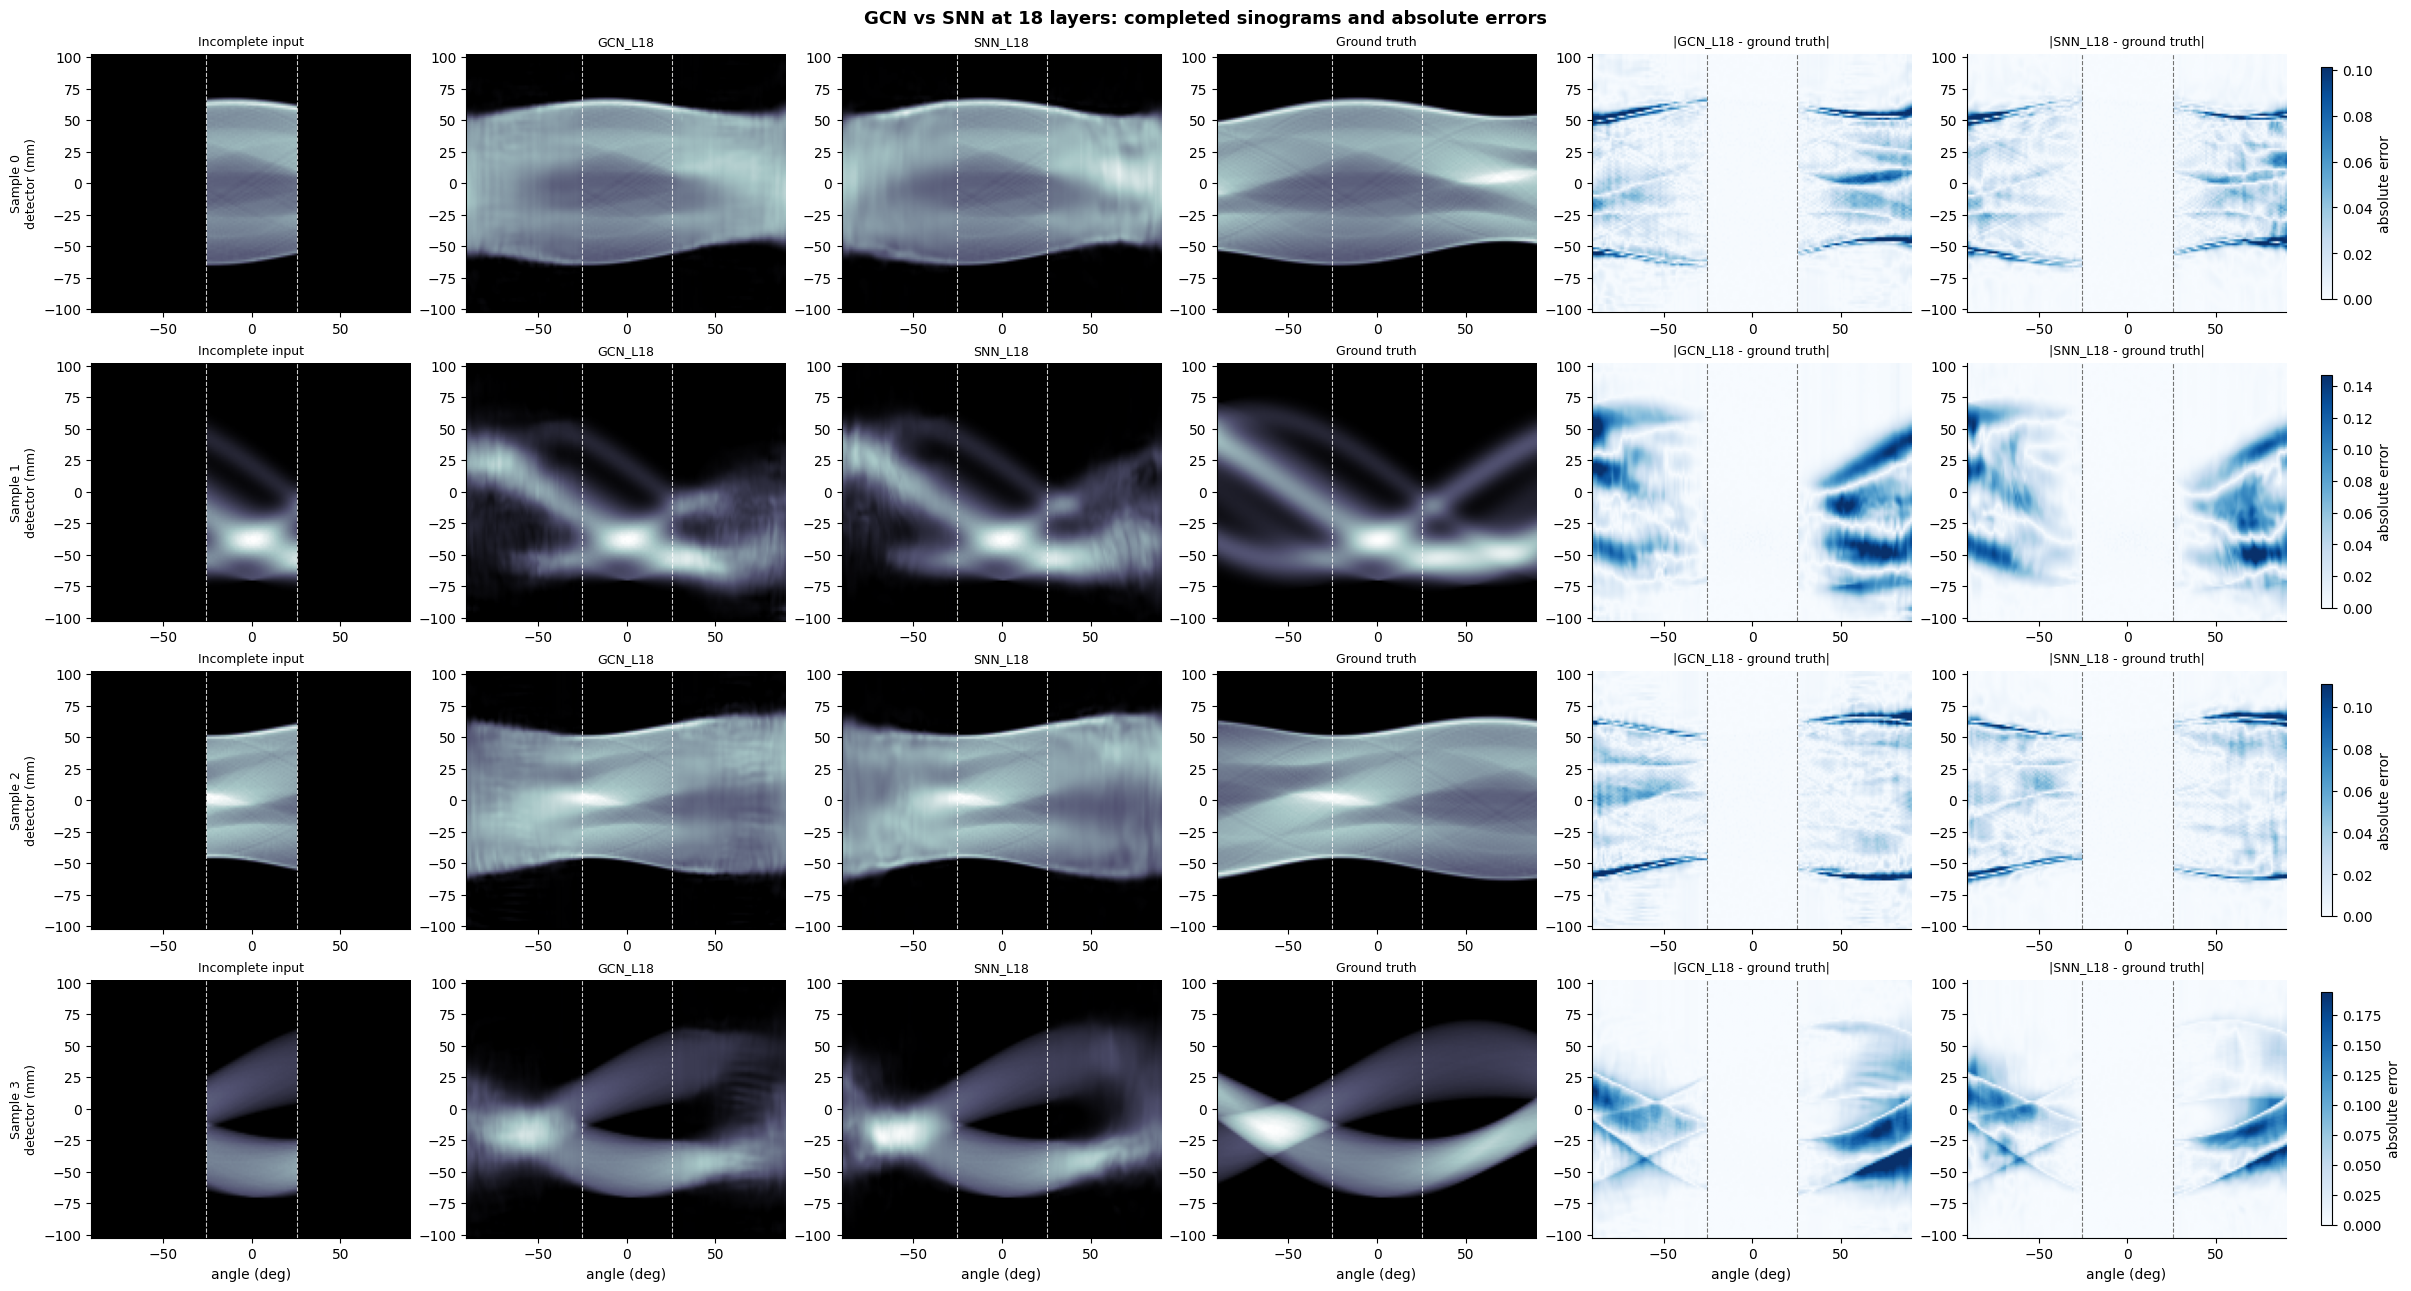

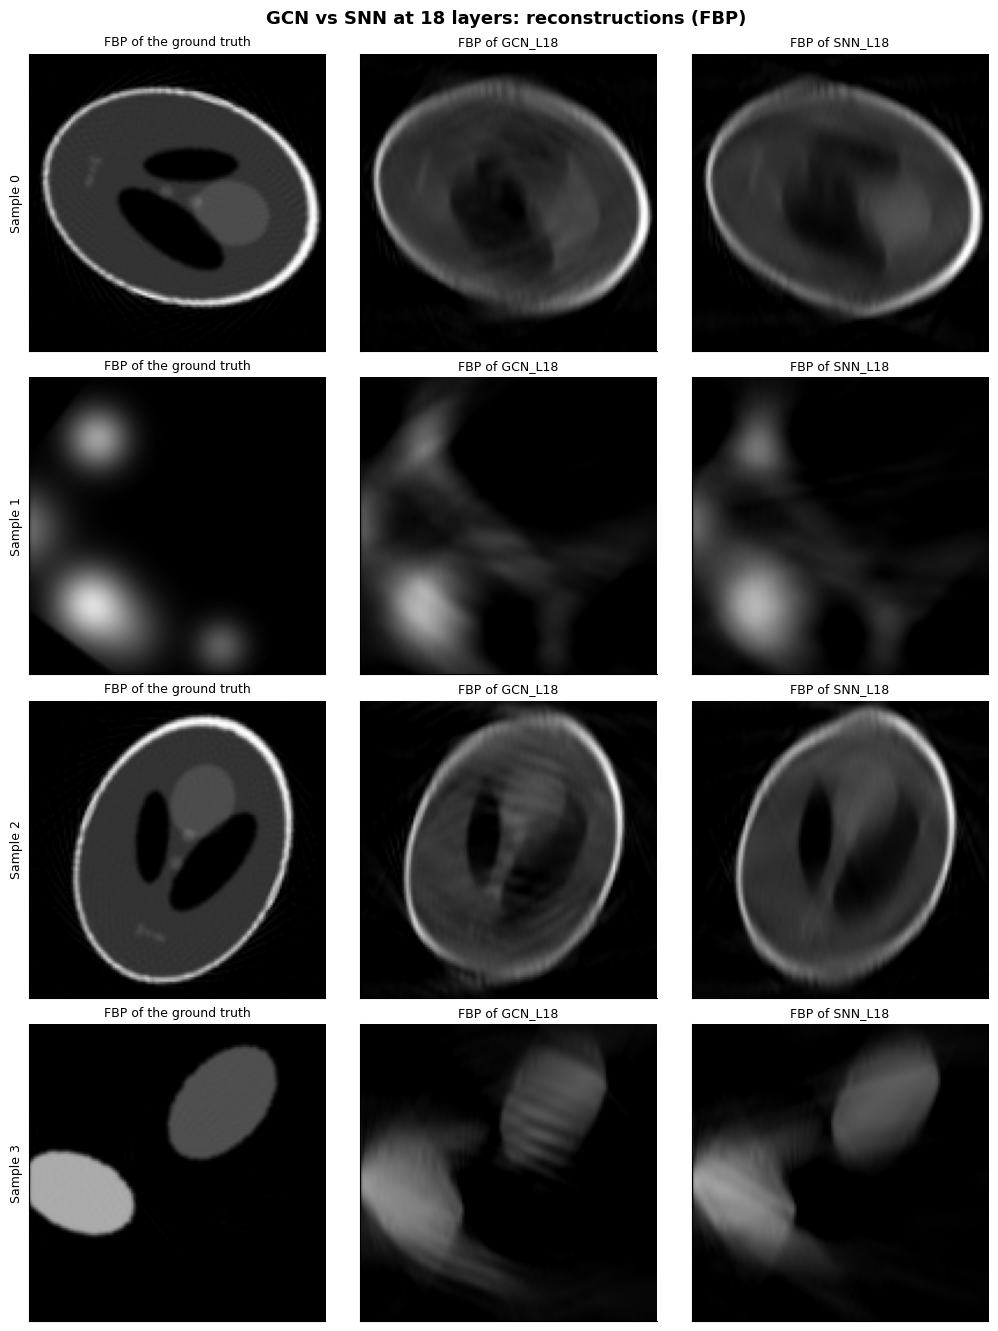

In [11]:
from scipy.stats import wilcoxon

OVERSMOOTHING_DEPTHS = (12, 18)       # the whole wedge is within reach (72° and 108° > 65°)
OVERSMOOTHING_SAMPLES = [0, 1, 2, 3]  # test samples fixed before looking at the results
PROFILE_DETECTORS = [40, 64, 88]      # detector pixels of the angular profiles
ALPHA = 0.05                          # level of the paired Wilcoxon tests

pairs = {L: (f"GCN_L{L}", f"SNN_L{L}") for L in OVERSMOOTHING_DEPTHS if f"GCN_L{L}" in models and f"SNN_L{L}" in models}
if not pairs:
    print("No GCN / SNN pair at 12 or 18 layers is loaded yet (Phase 3): the figures of this section are skipped.")
else:
    dataset_4 = SinogramCompletionDataset(max(OVERSMOOTHING_SAMPLES) + 1, split="test", noise_level=NOISE_LEVEL,
                                          geometry_config=geometry_config)
    samples_4 = {i: dataset_4[i] for i in OVERSMOOTHING_SAMPLES}
    predictions_4 = {(name, i): complete(models[name], samples_4[i][0])
                     for pair in pairs.values() for name in pair for i in OVERSMOOTHING_SAMPLES}

for L, (gcn, snn) in pairs.items():
    n_rows = len(OVERSMOOTHING_SAMPLES)
    fig, axes = plt.subplots(n_rows, 6, figsize=(24, 3.2 * n_rows), squeeze=False, layout="constrained")
    for row, i in enumerate(OVERSMOOTHING_SAMPLES):
        incomplete, full, _ = samples_4[i]
        full_np = full[0].numpy()
        errors = {name: np.abs(predictions_4[(name, i)] - full_np) for name in (gcn, snn)}
        error_max = max(1e-6, *(np.percentile(e[missing_views], 99) for e in errors.values()))
        panels = [(incomplete[0].numpy(), "Incomplete input", "bone", full_np.max()),
                  (predictions_4[(gcn, i)], gcn, "bone", full_np.max()),
                  (predictions_4[(snn, i)], snn, "bone", full_np.max()),
                  (full_np, "Ground truth", "bone", full_np.max()),
                  (errors[gcn], f"|{gcn} - ground truth|", "Blues", error_max),
                  (errors[snn], f"|{snn} - ground truth|", "Blues", error_max)]
        for ax, (image, title, cmap, vmax) in zip(axes[row], panels):
            shown = ax.imshow(image.T, cmap=cmap, origin="lower", aspect="auto", extent=sino_extent, vmin=0.0, vmax=vmax)
            for edge in window_edges:
                ax.axvline(edge, color="white" if cmap == "bone" else "#52514e", alpha=0.8, linestyle="--", linewidth=0.8)
            ax.set_title(title, fontsize=9)
        fig.colorbar(shown, ax=axes[row, 4:].tolist(), shrink=0.9, label="absolute error")
        axes[row, 0].set_ylabel(f"Sample {i}\ndetector (mm)", fontsize=9)
    for ax in axes[-1]:
        ax.set_xlabel("angle (deg)")
    fig.suptitle(f"GCN vs SNN at {L} layers: completed sinograms and absolute errors", fontsize=13, fontweight="bold")
    fig.savefig(FIG_DIR / f"oversmoothing_sinograms_L{L}.pdf", bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(n_rows, 3, figsize=(10, 3.3 * n_rows), squeeze=False, layout="constrained")
    for row, i in enumerate(OVERSMOOTHING_SAMPLES):
        sinograms = [(samples_4[i][1][0].numpy(), "FBP of the ground truth"),
                     (predictions_4[(gcn, i)], f"FBP of {gcn}"), (predictions_4[(snn, i)], f"FBP of {snn}")]
        for ax, (sinogram, title) in zip(axes[row], sinograms):
            ax.imshow(fbp(sinogram), cmap="gray", origin="lower", extent=image_extent, vmin=0.0, vmax=1.0)
            ax.set_title(title, fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
        axes[row, 0].set_ylabel(f"Sample {i}", fontsize=9)
    fig.suptitle(f"GCN vs SNN at {L} layers: reconstructions (FBP)", fontsize=13, fontweight="bold")
    fig.savefig(FIG_DIR / f"oversmoothing_fbp_L{L}.pdf", bbox_inches="tight")
    plt.show()

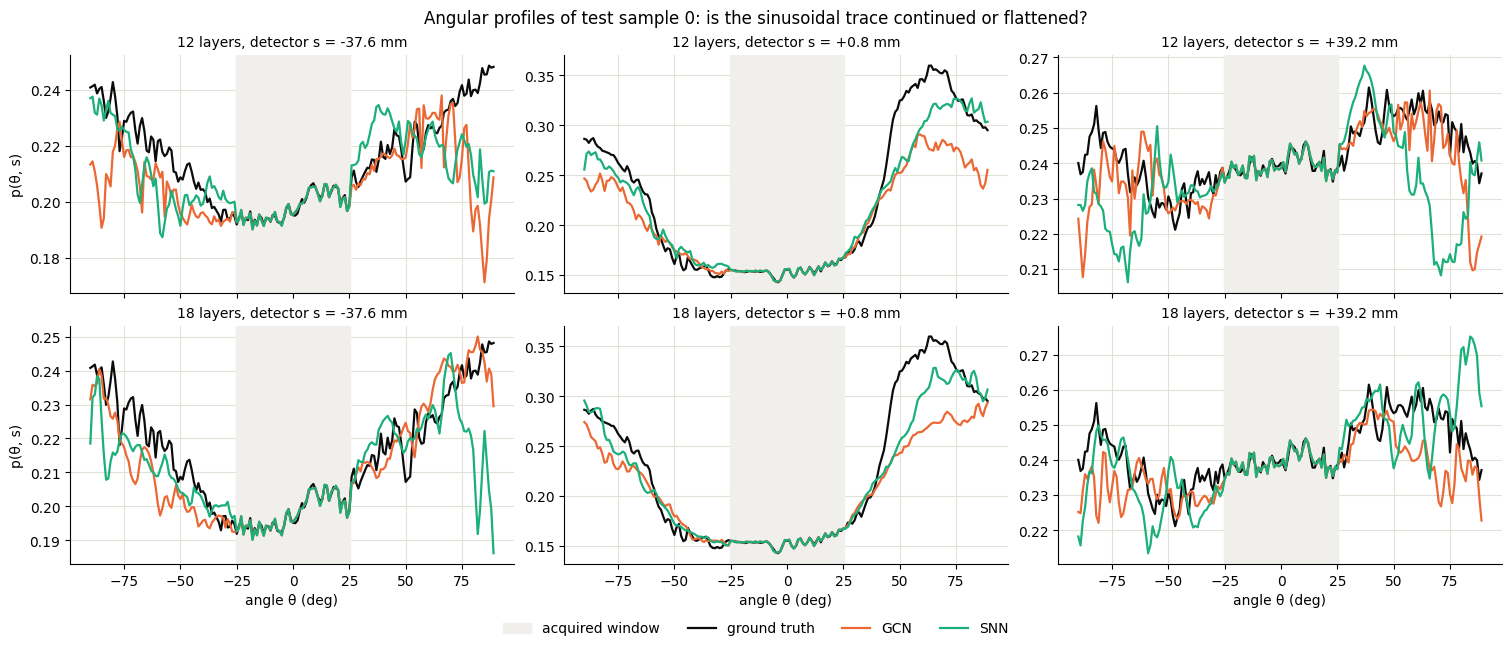

In [12]:
if pairs:
    profile_sample = OVERSMOOTHING_SAMPLES[0]
    truth = samples_4[profile_sample][1][0].numpy()
    fig, axes = plt.subplots(len(pairs), len(PROFILE_DETECTORS), figsize=(5 * len(PROFILE_DETECTORS), 3.2 * len(pairs)),
                             squeeze=False, sharex=True, layout="constrained")
    for row, (L, (gcn, snn)) in enumerate(pairs.items()):
        for col, pixel in enumerate(PROFILE_DETECTORS):
            ax = axes[row, col]
            ax.axvspan(*window_edges, color="#f0efec", label="acquired window")
            ax.plot(angles_deg, truth[:, pixel], color="#0b0b0b", linewidth=1.6, label="ground truth")
            ax.plot(angles_deg, predictions_4[(gcn, profile_sample)][:, pixel], color=FAMILY_COLORS["GCN"], linewidth=1.6, label="GCN")
            ax.plot(angles_deg, predictions_4[(snn, profile_sample)][:, pixel], color=FAMILY_COLORS["SNN"], linewidth=1.6, label="SNN")
            s_mm = (pixel - geometry_config.det_col_count / 2 + 0.5) * geometry_config.det_pixel_size_mm
            ax.set_title(f"{L} layers, detector s = {s_mm:+.1f} mm", fontsize=10)
            ax.grid(color="#e1e0d9", linewidth=0.8)
            ax.set_axisbelow(True)
        axes[row, 0].set_ylabel("p(θ, s)")
    for ax in axes[-1]:
        ax.set_xlabel("angle θ (deg)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncol=4, frameon=False)
    fig.suptitle(f"Angular profiles of test sample {profile_sample}: is the sinusoidal trace continued or flattened?", fontsize=12)
    fig.savefig(FIG_DIR / "oversmoothing_profiles.pdf", bbox_inches="tight")
    plt.show()

,in criterion,GCN mse_wedge,SNN mse_wedge,SNN better (samples),p mse_wedge,GCN angle ratio,SNN angle ratio,p |log angle ratio|,GCN detector ratio,SNN detector ratio
layers,,,,,,,,,,
12,yes,0.002699,0.002608,54%,2.409629e-01,3.219657,1.444082,3.396553e-18,0.487612,0.396007
18,yes,0.002399,0.001926,83%,1.177187e-21,1.138974,1.230833,5.401902e-01,0.446242,0.477580


Criterion NOT met (12 layers: SNN not significantly better on mse_wedge; 18 layers: SNN not significantly better on |log angle ratio|): conclusion (b) of the plan for the pre-registered test. Any other difference in the table is exploratory.


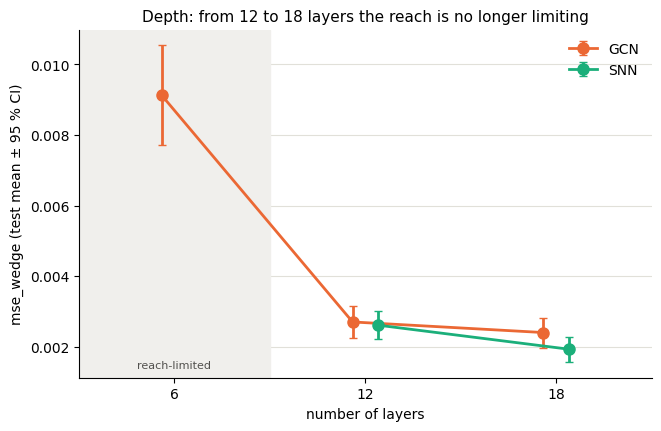

In [13]:
SMOOTHNESS_COLS = ["dirichlet_angle_ratio", "dirichlet_detector_ratio"]


def paired_wilcoxon(differences: pd.Series) -> float:
    """Two-sided p-value of the paired Wilcoxon signed-rank test (NaN if all differences are 0)."""
    try:
        return float(wilcoxon(differences).pvalue)
    except ValueError:
        return float("nan")


evaluated = set(results["Model"])
if not set(SMOOTHNESS_COLS) <= set(results.columns):
    print("The CSV has no Dirichlet-energy ratios: re-run python src_2D/evaluate_all.py.")
else:
    by_sample = {m: results[results["Model"] == m].set_index("Sample").sort_index() for m in evaluated}
    rows, verdicts = [], {}
    for L in PROTOCOL_DEPTHS:
        gcn, snn = f"GCN_L{L}", f"SNN_L{L}"
        if gcn not in evaluated or snn not in evaluated:
            continue
        a, b = by_sample[gcn].align(by_sample[snn], join="inner", axis=0)
        mse_diff = b["mse_wedge"] - a["mse_wedge"]  # < 0: the SNN is better
        angle_gap = np.abs(np.log(b["dirichlet_angle_ratio"])) - np.abs(np.log(a["dirichlet_angle_ratio"]))  # < 0: SNN closer to 1
        mse_p, angle_p = paired_wilcoxon(mse_diff), paired_wilcoxon(angle_gap)
        if L in OVERSMOOTHING_DEPTHS:
            verdicts[L] = {"mse_wedge": bool(np.median(mse_diff) < 0 and mse_p < ALPHA),
                           "|log angle ratio|": bool(np.median(angle_gap) < 0 and angle_p < ALPHA)}
        rows.append({
            "layers": L, "in criterion": "yes" if L in OVERSMOOTHING_DEPTHS else "no (reach-limited)",
            "GCN mse_wedge": a["mse_wedge"].mean(), "SNN mse_wedge": b["mse_wedge"].mean(),
            "SNN better (samples)": f"{(mse_diff < 0).mean():.0%}", "p mse_wedge": mse_p,
            "GCN angle ratio": a["dirichlet_angle_ratio"].mean(), "SNN angle ratio": b["dirichlet_angle_ratio"].mean(),
            "p |log angle ratio|": angle_p,
            "GCN detector ratio": a["dirichlet_detector_ratio"].mean(), "SNN detector ratio": b["dirichlet_detector_ratio"].mean(),
        })
    if rows:
        comparison_table = pd.DataFrame(rows).set_index("layers")
        display(comparison_table)
        export_table(comparison_table, "gcn_vs_snn")

    if len(verdicts) < len(OVERSMOOTHING_DEPTHS):
        print("The criterion needs GCN and SNN at 12 and 18 layers in the CSV: waiting for Phase 3.")
    elif all(all(tests.values()) for tests in verdicts.values()):
        print("Criterion MET at 12 and 18 layers: the shift transport limits the dilution of the information along the angle.")
    else:
        failed = "; ".join(f"{L} layers: SNN not significantly better on {', '.join(m for m, ok in tests.items() if not ok)}"
                           for L, tests in verdicts.items() if not all(tests.values()))
        print(f"Criterion NOT met ({failed}): conclusion (b) of the plan for the pre-registered test. "
              "Any other difference in the table is exploratory.")

    depths_present = [L for L in PROTOCOL_DEPTHS if f"GCN_L{L}" in evaluated or f"SNN_L{L}" in evaluated]
    if depths_present:
        fig, ax = plt.subplots(figsize=(6.5, 4.2), layout="constrained")
        ax.axvspan(PROTOCOL_DEPTHS[0] - 3, (PROTOCOL_DEPTHS[0] + PROTOCOL_DEPTHS[1]) / 2, color="#f0efec")
        ax.text(PROTOCOL_DEPTHS[0], 0.02, "reach-limited", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontsize=8, color="#52514e")
        for fam, dodge in (("GCN", -0.4), ("SNN", 0.4)):  # side by side, so that the error bars never hide each other
            present = [L for L in depths_present if f"{fam}_L{L}" in evaluated]
            if not present:
                continue
            values = [by_sample[f"{fam}_L{L}"]["mse_wedge"] for L in present]
            ax.errorbar([L + dodge for L in present], [v.mean() for v in values], yerr=[1.96 * v.sem() for v in values],
                        color=FAMILY_COLORS[fam], marker="o", markersize=8, linewidth=2, capsize=3, label=fam)
        ax.set_xticks(PROTOCOL_DEPTHS)
        ax.set_xlim(PROTOCOL_DEPTHS[0] - 3, PROTOCOL_DEPTHS[-1] + 3)
        ax.set_xlabel("number of layers")
        ax.set_ylabel("mse_wedge (test mean ± 95 % CI)")
        ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.legend(frameon=False)
        ax.set_title("Depth: from 12 to 18 layers the reach is no longer limiting", fontsize=11)
        fig.savefig(FIG_DIR / "oversmoothing_depth_trend.pdf", bbox_inches="tight")
        plt.show()

## 5. Data regime: U-Net vs U-Net + HLCC loss with 200 and 2000 training phantoms

The four runs of `scripts/launch_unet_hlcc_data_study.sh` (`docs/hlcc_projection.md`, section 7): the same U-Net
trained with the MSE alone (`UNet2D`) or with the HLCC penalty of orders 0-1 (`UNet2dHLCC`, λ = 1e-3), on the 2000
phantoms of the protocol or on 200 phantoms seen 10 times per epoch (`_N200`). The number of optimisation steps,
validations and schedules is the same: only the number of distinct phantoms changes. Each network is also evaluated
followed by the HLCC moment regression (`_P4`, no training).

- First table: test metrics. `hlcc_residual_1` = share of the order-1 moment curve of the output outside its harmonic
  space (0 for a consistent sinogram): what the HLCC loss penalises.
- Second table: paired effects on the same test samples (Wilcoxon signed-rank test on `mse_wedge`).
- One seed per run: an effect of a few percent may be within the run-to-run noise.


In [14]:
DATA_REGIMES = {200: "_N200", 2000: ""}  # training phantoms -> tag of the run
UNETS = ("UNet2D", "UNet2dHLCC")
regime_models = [f"{base}{tag}{p4}" for tag in DATA_REGIMES.values() for base in UNETS for p4 in ("", "_P4")]
missing = [m for m in regime_models if m not in per_sample]
if missing:
    print(f"Not evaluated: {missing}. Run python src_2D/evaluate_all.py (its default list includes them).")
else:
    rows = []
    for n, tag in DATA_REGIMES.items():
        for base in UNETS:
            for p4 in ("", "_P4"):
                r = per_sample[f"{base}{tag}{p4}"]
                rows.append({"Training phantoms": n, "Model": base, "Moment regression": "P4" if p4 else "—",
                             "mse_wedge": f"{r['mse_wedge'].mean():.2e} ± {r['mse_wedge'].std():.2e}",
                             "img_psnr": f"{r['img_psnr'].mean():.2f}", "img_ssim": f"{r['img_ssim'].mean():.4f}",
                             "hlcc_residual_1": f"{r['hlcc_residual_1'].mean():.4f}"})
    regime_table = pd.DataFrame(rows).set_index(["Training phantoms", "Model", "Moment regression"])
    display(regime_table)
    export_table(regime_table, "data_regime_metrics")

    def paired_effect(reference: str, candidate: str) -> dict:
        """Change of mse_wedge from reference to candidate on the same test samples."""
        a, b = per_sample[reference]["mse_wedge"].align(per_sample[candidate]["mse_wedge"], join="inner")
        return {"mse_wedge": f"{a.mean():.2e} → {b.mean():.2e}", "Change": f"{100 * (b.mean() / a.mean() - 1):+.1f} %",
                "Better on": f"{(b < a).sum()} / {len(a)}", "Wilcoxon p": f"{wilcoxon(b - a).pvalue:.2g}"}

    effect_rows = []
    for n, tag in DATA_REGIMES.items():
        for effect, reference, candidate in (
            ("HLCC loss (UNet2dHLCC vs UNet2D)", f"UNet2D{tag}", f"UNet2dHLCC{tag}"),
            ("HLCC loss, both followed by P4", f"UNet2D{tag}_P4", f"UNet2dHLCC{tag}_P4"),
            ("P4 after UNet2D", f"UNet2D{tag}", f"UNet2D{tag}_P4"),
            ("P4 after UNet2dHLCC", f"UNet2dHLCC{tag}", f"UNet2dHLCC{tag}_P4"),
        ):
            effect_rows.append({"Effect": effect, "Training phantoms": n, **paired_effect(reference, candidate)})
    effect_table = pd.DataFrame(effect_rows).set_index(["Effect", "Training phantoms"]).sort_index(level=0, sort_remaining=False)
    display(effect_table)
    export_table(effect_table, "data_regime_effects")


mse_wedge img_psnr  \
Training phantoms Model      Moment regression                                 
200               UNet2D     —                  2.75e-03 ± 3.27e-03    19.53   
                             P4                 2.01e-03 ± 2.03e-03    19.77   
                  UNet2dHLCC —                  2.71e-03 ± 3.40e-03    19.55   
                             P4                 1.99e-03 ± 2.05e-03    19.79   
2000              UNet2D     —                  8.15e-04 ± 1.10e-03    23.35   
                             P4                 7.26e-04 ± 9.28e-04    23.41   
                  UNet2dHLCC —                  8.17e-04 ± 1.16e-03    23.43   
                             P4                 7.36e-04 ± 9.77e-04    23.47   

                                               img_ssim hlcc_residual_1  
Training phantoms Model      Moment regression                           
200               UNet2D     —                   0.3762          0.0444  
                             P4                  0.3808          0.0092  
                  UNet2dHLCC —                   0.3844          0.0330  
                             P4                  0.3883          0.0072  
2000              UNet2D     —                   0.5337          0.0121  
                             P4                  0.5369          0.0019  
                  UNet2dHLCC —                   0.5282          0.0091  
                             P4                  0.5304          0.0015

mse_wedge  \
Effect                           Training phantoms                        
HLCC loss (UNet2dHLCC vs UNet2D) 200                2.75e-03 → 2.71e-03   
                                 2000               8.15e-04 → 8.17e-04   
HLCC loss, both followed by P4   200                2.01e-03 → 1.99e-03   
                                 2000               7.26e-04 → 7.36e-04   
P4 after UNet2D                  200                2.75e-03 → 2.01e-03   
                                 2000               8.15e-04 → 7.26e-04   
P4 after UNet2dHLCC              200                2.71e-03 → 1.99e-03   
                                 2000               8.17e-04 → 7.36e-04   

                                                     Change  Better on  \
Effect                           Training phantoms                       
HLCC loss (UNet2dHLCC vs UNet2D) 200                 -1.4 %  117 / 200   
                                 2000                +0.2 %  122 / 200   
HLCC loss, both followed by P4   200                 -1.2 %  109 / 200   
                                 2000                +1.4 %  116 / 200   
P4 after UNet2D                  200                -26.8 %  199 / 200   
                                 2000               -11.0 %  189 / 200   
P4 after UNet2dHLCC              200                -26.6 %  199 / 200   
                                 2000                -9.9 %  185 / 200   

                                                   Wilcoxon p  
Effect                           Training phantoms             
HLCC loss (UNet2dHLCC vs UNet2D) 200                    0.036  
                                 2000                   0.067  
HLCC loss, both followed by P4   200                      0.3  
                                 2000                    0.54  
P4 after UNet2D                  200                  1.6e-34  
                                 2000                 1.8e-31  
P4 after UNet2dHLCC              200                  1.5e-34  
                                 2000                 1.7e-29